In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

maitreyeemajumdar_final_batch1_dataset_path = kagglehub.dataset_download('maitreyeemajumdar/final-batch1-dataset')
maitreyeemajumdar_final_batch2_dataset_path = kagglehub.dataset_download('maitreyeemajumdar/final-batch2-dataset')

print('Data source import complete.')


# VerteNet: Cobb Angle Detection from Spinal X-Rays
### Official VerteNet Architecture — Comparative Hyperparameter Analysis

**Real Architecture (from official ZIP):**
- Backbone: **EfficientNetV2-S** (timm, `features_only=True`), channels [24, 48, 64, 160, 256]
- Decoder: **DecNet_vertenet** with `CombinationModule_proposed` — Dual-Resolution Cross-Attention (DR__CrossAttention + DR__SelfAttention) with patch-based processing
- Output heads (CenterNet-style): `hm` (heatmap, FocalLoss), `reg` (offset, L1), `wh` (corner offsets, L1)
- **Phase 1**: Pre-train on Batch 1 (512×512, COCO JSON / .mat landmarks)
- **Phase 2**: Fine-tune on Batch 2 (high-res, YOLO + .mat)
- **Experiments**: 5 configurations varying LR, batch size, dropout (head_conv), scheduler, ExponentialLR gamma

---
## 1. Install Dependencies

In [ ]:
!pip install -q timm einops scipy scikit-learn pycocotools
import importlib, subprocess
for pkg in ['timm','einops','scipy','sklearn','pycocotools']:
    try: importlib.import_module(pkg.split('.')[0]); print(f'{pkg} OK')
    except: subprocess.run(['pip','install','-q',pkg])

timm OK
einops OK
scipy OK
sklearn OK
pycocotools OK


---
## 2. Imports & Global Config

In [ ]:
import os, sys, json, csv, time, math, random, copy, glob, pickle, numbers, warnings
import numpy as np
import pandas as pd
import scipy.io as sio
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from einops import rearrange

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import timm

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
torch.backends.cudnn.deterministic = True

Device : cuda
GPU    : Tesla T4


---
## 3. Dataset Paths — Update to Match Your Kaggle Input Folders

In [ ]:
# ── Batch 1: 512×512 JPEG images + COCO-format JSON ─────────────────────
BATCH1_ROOT  = '/kaggle/input/datasets/maitreyeemajumdar/final-batch1-dataset/final-batch1-dataset'   # <-- UPDATE
BATCH1_IMG   = os.path.join(BATCH1_ROOT, 'images')
BATCH1_JSON  = os.path.join(BATCH1_ROOT, 'annotations.json')

# Optional: if Batch 1 also has .mat labels in the VerteNet format
# (data/train, data/val, labels/train, labels/val under this root)
BATCH1_MAT_ROOT = BATCH1_ROOT   # same root if organised like VerteNet's dataPath

# ── Batch 2: High-quality images ─────────────────────────────────────────
BATCH2_ROOT      = '/kaggle/input/datasets/maitreyeemajumdar/final-batch2-dataset/final-batch2-dataset'   # <-- UPDATE
BATCH2_IMAGES_A  = os.path.join(BATCH2_ROOT, 'Images')
BATCH2_LABELS_A  = os.path.join(BATCH2_ROOT, 'Labels')    # YOLO .txt
BATCH2_IMAGES_B  = os.path.join(BATCH2_ROOT, 'Images2')
BATCH2_LABELS_B  = os.path.join(BATCH2_ROOT, 'Labels2')   # YOLO .txt
BATCH2_TRAIN_DIR = os.path.join(BATCH2_ROOT, 'Labels2', 'train')  # .mat per image
BATCH2_ANGLES_CSV    = os.path.join(BATCH2_ROOT, 'Labels2', 'angles.csv')
BATCH2_FILENAMES_CSV = os.path.join(BATCH2_ROOT, 'Labels2', 'filenames.csv')
BATCH2_LANDMARKS_CSV = os.path.join(BATCH2_ROOT, 'Labels2', 'landmarks.csv')
BATCH2_LANDMARKS_MAT = os.path.join(BATCH2_ROOT, 'Labels2', 'landmarks.mat')

# ── Output directory ─────────────────────────────────────────────────────
OUTPUT_DIR  = '/kaggle/working/vertenet_results'
WEIGHTS_DIR = os.path.join(OUTPUT_DIR, 'weights')
LOGS_DIR    = os.path.join(OUTPUT_DIR, 'logs')
FIGS_DIR    = os.path.join(OUTPUT_DIR, 'figures')
for d in [OUTPUT_DIR, WEIGHTS_DIR, LOGS_DIR, FIGS_DIR]:
    os.makedirs(d, exist_ok=True)

# ── VerteNet fixed training settings ────────────────────────────────────
INPUT_H    = 512    # resize height (official default 1024; reduce for GPU memory)
INPUT_W    = 512    # resize width
DOWN_RATIO = 4      # stride; heatmap size = INPUT_H//DOWN_RATIO
NUM_CLASSES = 1     # single heatmap channel (all vertebra centres share one channel)
K           = 17     # top-K vertebrae decoded per image (6 in official code)
CONF_THRESH = 0.1
NUM_WORKERS = 2
VAL_SPLIT   = 0.15

print('Paths configured. OUTPUT_DIR:', OUTPUT_DIR)

Paths configured. OUTPUT_DIR: /kaggle/working/vertenet_results


---
## 4. Core Utilities (verbatim from official VerteNet)
### 4.1 draw_gaussian.py

In [ ]:
# ── Verbatim from VerteNet-main/draw_gaussian.py ─────────────────────────
import numpy as np

def gaussian2D(shape, sigma=1):
    m, n = [(ss - 1.) / 2. for ss in shape]
    y, x = np.ogrid[-m:m+1,-n:n+1]
    h = np.exp(-(x * x + y * y) / (2 * sigma * sigma))
    h[h < np.finfo(h.dtype).eps * h.max()] = 0
    return h

def gaussian_radius(det_size, min_overlap=0.7):
    height, width = det_size
    a1  = 1
    b1  = (height + width)
    c1  = width * height * (1 - min_overlap) / (1 + min_overlap)
    sq1 = np.sqrt(b1 ** 2 - 4 * a1 * c1)
    r1  = (b1 + sq1) / 2
    a2  = 4
    b2  = 2 * (height + width)
    c2  = (1 - min_overlap) * width * height
    sq2 = np.sqrt(b2 ** 2 - 4 * a2 * c2)
    r2  = (b2 + sq2) / 2
    a3  = 4 * min_overlap
    b3  = -2 * min_overlap * (height + width)
    c3  = (min_overlap - 1) * width * height
    sq3 = np.sqrt(b3 ** 2 - 4 * a3 * c3)
    r3  = (b3 + sq3) / 2
    return min(r1, r2, r3)

def draw_umich_gaussian(heatmap, center, radius, k=1):
    diameter = 2 * radius + 1
    gaussian = gaussian2D((diameter, diameter), sigma=diameter / 6)
    x, y = int(center[0]), int(center[1])
    height, width = heatmap.shape[0:2]
    left, right = min(x, radius), min(width - x, radius + 1)
    top, bottom = min(y, radius), min(height - y, radius + 1)
    masked_heatmap  = heatmap[y - top:y + bottom, x - left:x + right]
    masked_gaussian = gaussian[radius - top:radius + bottom, radius - left:radius + right]
    if min(masked_gaussian.shape) > 0 and min(masked_heatmap.shape) > 0:
        np.maximum(masked_heatmap, masked_gaussian * k, out=masked_heatmap)
    return heatmap

print('draw_gaussian utilities loaded.')

draw_gaussian utilities loaded.


### 4.2 transform.py (verbatim from official VerteNet)

In [ ]:
# ── Verbatim from VerteNet-main/transform.py ─────────────────────────────
import numpy as np
import cv2
import random
import math

def rescale_pts(pts, down_ratio):
    return np.asarray(pts, np.float32) / float(down_ratio)

class Compose(object):
    def __init__(self, transforms): self.transforms = transforms
    def __call__(self, img, pts):
        for t in self.transforms: img, pts = t(img, pts)
        return img, pts

class ConvertImgFloat(object):
    def __call__(self, img, pts):
        return img.astype(np.float32), pts

class RandomMirror_w(object):
    def __call__(self, img, pts):
        _, w, _ = img.shape
        if random.randint(0,1):
            img = img[:, ::-1, :]
            pts[:, 0] = w - pts[:, 0]
        return img, pts

class PhotometricDistort(object):
    def __call__(self, img, pts):
        # brightness
        if random.randint(0,1):
            delta = random.uniform(-32, 32)
            img += delta
        # contrast
        if random.randint(0,1):
            alpha = random.uniform(0.5, 1.5)
            img *= alpha
        return img, pts

class Expand(object):
    def __init__(self, max_scale=1.5, mean=(0, 0, 0)):
        self.max_scale = max_scale
        self.mean = mean
    def __call__(self, img, pts):
        if random.randint(0, 1):
            return img, pts
        h, w, _ = img.shape
        scale  = random.uniform(1, self.max_scale)
        nh, nw = int(h * scale), int(w * scale)
        top  = random.randint(0, nh - h)
        left = random.randint(0, nw - w)
        canvas = np.zeros((nh, nw, 3), dtype=img.dtype)
        for c, v in enumerate(self.mean):
            canvas[:, :, c] = v
        canvas[top:top+h, left:left+w] = img
        pts = pts.copy()
        pts[:, 0] += left
        pts[:, 1] += top
        return canvas, pts

class Resize(object):
    def __init__(self, h, w): self.h, self.w = h, w
    def __call__(self, img, pts):
        oh, ow = img.shape[:2]
        img = cv2.resize(img, (self.w, self.h))
        pts = pts.copy().astype(np.float32)
        pts[:, 0] = pts[:, 0] / ow * self.w
        pts[:, 1] = pts[:, 1] / oh * self.h
        return img, pts

print('Transform utilities loaded.')

Transform utilities loaded.


### 4.3 pre_proc.py (verbatim from official VerteNet)

In [ ]:
# ── Verbatim from VerteNet-main/pre_proc.py ──────────────────────────────
import cv2, math, numpy as np

def processing_test(image, input_h, input_w):
    image = cv2.resize(image, (input_w, input_h))
    out_image = image.astype(np.float32) / 255.
    out_image = out_image - 0.5
    out_image = out_image.transpose(2, 0, 1).reshape(1, 3, input_h, input_w)
    return torch.from_numpy(out_image)

def rearrange_pts(pts):
    boxes, centers = [], []
    for k in range(0, len(pts), 4):
        pts_4 = pts[k:k+4, :]
        x_inds = np.argsort(pts_4[:, 0])
        pt_l, pt_r = pts_4[x_inds[:2], :], pts_4[x_inds[2:], :]
        y_inds_l, y_inds_r = np.argsort(pt_l[:, 1]), np.argsort(pt_r[:, 1])
        tl, bl = pt_l[y_inds_l[0]], pt_l[y_inds_l[1]]
        tr, br = pt_r[y_inds_r[0]], pt_r[y_inds_r[1]]
        boxes.extend([tl, tr, bl, br])
        centers.append(np.mean(pts_4, axis=0))
    bboxes  = np.asarray(boxes,   np.float32)
    centers = np.asarray(centers, np.float32)
    sort_tb = np.argsort(centers[:, 1])
    new_bboxes = []
    for si in sort_tb:
        new_bboxes.extend(bboxes[4*si:4*si+4])
    return np.asarray(new_bboxes, np.float32)

def generate_ground_truth(image, pts_2, image_h, image_w, img_id, num_vertebrae=17):
    ind      = np.zeros(num_vertebrae, dtype=np.int64)
    wh       = np.zeros((num_vertebrae, 8), dtype=np.float32)
    reg      = np.zeros((num_vertebrae, 2), dtype=np.float32)
    reg_mask = np.zeros(num_vertebrae,      dtype=np.uint8)
    hm       = np.zeros((1, image_h, image_w), dtype=np.float32)
    n_verts  = pts_2.shape[0] // 4
    for k in range(min(n_verts, num_vertebrae)):
        pts    = pts_2[4*k:4*k+4, :]
        bbox_h = np.mean([np.linalg.norm(pts[0]-pts[2]), np.linalg.norm(pts[1]-pts[3])])
        bbox_w = np.mean([np.linalg.norm(pts[0]-pts[1]), np.linalg.norm(pts[2]-pts[3])])
        cen_x, cen_y = np.mean(pts, axis=0)
        ct     = np.asarray([cen_x, cen_y], dtype=np.float32)
        ct_int = ct.astype(np.int32)
        ct_int[0] = np.clip(ct_int[0], 0, image_w - 1)
        ct_int[1] = np.clip(ct_int[1], 0, image_h - 1)
        radius = max(0, int(gaussian_radius((math.ceil(bbox_h), math.ceil(bbox_w)))))
        draw_umich_gaussian(hm[0], ct_int, radius=radius)
        ind[k]      = ct_int[1] * image_w + ct_int[0]
        reg[k]      = ct - ct_int
        reg_mask[k] = 1
        for i in range(4):
            wh[k, 2*i:2*i+2] = ct - pts[i]
    return {'input': image, 'hm': hm, 'ind': ind,
            'reg': reg, 'wh': wh, 'reg_mask': reg_mask}



def compose_aug(image_h, image_w):
    return Compose([
        ConvertImgFloat(),
        PhotometricDistort(),
        Expand(max_scale=1.5, mean=(0,0,0)),
        RandomMirror_w(),
        Resize(h=image_h, w=image_w),
    ])

def compose_val(image_h, image_w):
    return Compose([ConvertImgFloat(), Resize(h=image_h, w=image_w)])

def processing_train(image, pts, image_h, image_w, down_ratio, aug_label):
    aug_fn = compose_aug(image_h, image_w) if aug_label else compose_val(image_h, image_w)
    out_image, pts = aug_fn(image.copy(), pts)
    out_image = np.clip(out_image, 0., 255.)
    out_image = np.transpose(out_image / 255. - 0.5, (2, 0, 1))
    pts = rearrange_pts(pts)
    pts2 = rescale_pts(pts, down_ratio=down_ratio)
    return np.asarray(out_image, np.float32), pts2

print('pre_proc utilities loaded.')

pre_proc utilities loaded.


In [ ]:
# ── Rotation augmentation (applied before Gaussian GT generation) ─────────
import random as _random

def apply_rotation_aug(image, pts, max_angle=8.0, rot_p=0.4):
    """
    Randomly rotate image + landmarks by ±max_angle degrees.
    image : (H, W, 3) uint8 or float32
    pts   : (N, 2) x,y pixel coordinates
    Returns rotated image and rotated pts (same types as input).
    """
    if _random.random() > rot_p:
        return image, pts

    angle = _random.uniform(-max_angle, max_angle)
    h, w  = image.shape[:2]
    M     = cv2.getRotationMatrix2D((w / 2.0, h / 2.0), angle, 1.0)

    rotated_img = cv2.warpAffine(
        image, M, (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REFLECT_101)

    if pts is not None and len(pts) > 0:
        pts_h = np.hstack([pts, np.ones((len(pts), 1), dtype=np.float32)])
        rotated_pts = (M @ pts_h.T).T   # (N, 2)
        # clamp to image bounds
        rotated_pts[:, 0] = np.clip(rotated_pts[:, 0], 0, w - 1)
        rotated_pts[:, 1] = np.clip(rotated_pts[:, 1], 0, h - 1)
        return rotated_img, rotated_pts.astype(pts.dtype)

    return rotated_img, pts

print('Rotation augmentation loaded.')

Rotation augmentation loaded.


### 4.4 decoder.py (verbatim from official VerteNet)

In [ ]:
# ── Verbatim from VerteNet-main/decoder.py ───────────────────────────────
class DecDecoder:
    def __init__(self, K=17, conf_thresh=0.1):
        self.K, self.conf_thresh = K, conf_thresh

    def _gather_feat(self, feat, ind, mask=None):
        dim = feat.size(2)
        ind = ind.unsqueeze(2).expand(ind.size(0), ind.size(1), dim)
        feat = feat.gather(1, ind)
        if mask is not None:
            mask = mask.unsqueeze(2).expand_as(feat)
            feat = feat[mask].view(-1, dim)
        return feat

    def _tranpose_and_gather_feat(self, feat, ind):
        # FIX: capture channel dim BEFORE permute so view uses C not W
        b, c, h, w = feat.shape
        feat = feat.permute(0, 2, 3, 1).contiguous().view(b, -1, c)
        return self._gather_feat(feat, ind)

    def _nms(self, heat, kernel=3):
        hmax = F.max_pool2d(heat, (kernel, kernel), stride=1, padding=(kernel - 1) // 2)
        return heat * (hmax == heat).float()

    def _topk(self, scores):
        batch, cat, height, width = scores.size()
        topk_scores, topk_inds = torch.topk(scores.view(batch, cat, -1), self.K)
        topk_inds = topk_inds % (height * width)
        topk_ys   = (topk_inds // width).float()
        topk_xs   = (topk_inds %  width).float()
        topk_score, topk_ind = torch.topk(topk_scores.view(batch, -1), self.K)
        topk_inds = self._gather_feat(topk_inds.view(batch, -1, 1), topk_ind).view(batch, self.K)
        topk_ys   = self._gather_feat(topk_ys.view(batch, -1, 1),   topk_ind).view(batch, self.K)
        topk_xs   = self._gather_feat(topk_xs.view(batch, -1, 1),   topk_ind).view(batch, self.K)
        return topk_score, topk_inds, topk_ys, topk_xs

    def ctdet_decode(self, heat, wh, reg):
        batch, c, height, width = heat.size()
        heat   = self._nms(heat)
        scores, inds, ys, xs = self._topk(heat)
        scores = scores.view(batch, self.K, 1)
        reg    = self._tranpose_and_gather_feat(reg, inds).view(batch, self.K, 2)
        xs     = xs.view(batch, self.K, 1) + reg[:, :, 0:1]
        ys     = ys.view(batch, self.K, 1) + reg[:, :, 1:2]
        wh     = self._tranpose_and_gather_feat(wh, inds).view(batch, self.K, 8)
        tl_x = xs - wh[:, :, 0:1]; tl_y = ys - wh[:, :, 1:2]
        tr_x = xs - wh[:, :, 2:3]; tr_y = ys - wh[:, :, 3:4]
        bl_x = xs - wh[:, :, 4:5]; bl_y = ys - wh[:, :, 5:6]
        br_x = xs - wh[:, :, 6:7]; br_y = ys - wh[:, :, 7:8]
        pts = torch.cat([xs, ys, tl_x, tl_y, tr_x, tr_y, bl_x, bl_y, br_x, br_y, scores], dim=2).squeeze(0)
        return pts.data.cpu().numpy()

print('Decoder loaded.')

Decoder loaded.


### 4.5 loss.py (verbatim from official VerteNet)

In [ ]:
# ── Verbatim from VerteNet-main/loss.py ──────────────────────────────────
class RegL1Loss(nn.Module):
    def __init__(self): super().__init__()

    def _gather_feat(self, feat, ind, mask=None):
        dim = feat.size(2)
        ind = ind.unsqueeze(2).expand(ind.size(0), ind.size(1), dim)
        feat = feat.gather(1, ind)
        if mask is not None:
            mask = mask.unsqueeze(2).expand_as(feat)
            feat = feat[mask].view(-1, dim)
        return feat

    def _tranpose_and_gather_feat(self, feat, ind):
        # FIX: capture channel dim BEFORE permute so view uses C not W
        b, c, h, w = feat.shape
        feat = feat.permute(0, 2, 3, 1).contiguous().view(b, -1, c)
        return self._gather_feat(feat, ind)

    def forward(self, output, mask, ind, target):
        pred = self._tranpose_and_gather_feat(output, ind)
        mask = mask.unsqueeze(2).expand_as(pred).float()
        loss = F.l1_loss(pred * mask, target * mask, reduction='sum')
        return loss / (mask.sum() + 1e-4)


class FocalLoss(nn.Module):
    def __init__(self): super().__init__()
    def forward(self, pred, gt):
        pos_inds    = gt.eq(1).float()
        neg_inds    = gt.lt(1).float()
        neg_weights = torch.pow(1 - gt, 4)
        pos_loss = torch.log(pred + 1e-7) * torch.pow(1 - pred, 2) * pos_inds
        neg_loss = torch.log(1 - pred + 1e-7) * torch.pow(pred, 2) * neg_weights * neg_inds
        num_pos  = pos_inds.sum()
        loss = -(pos_loss.sum() + neg_loss.sum()) / (num_pos + 1e-4)
        return loss


class LossAll(nn.Module):
    def __init__(self, wh_weight=1.0, off_weight=1.0):
        super().__init__()
        self.L_hm  = FocalLoss()
        self.L_off = RegL1Loss()
        self.L_wh  = RegL1Loss()
        self.wh_weight  = wh_weight
        self.off_weight = off_weight

    def forward(self, pr_decs, gt_batch):
        hm_loss  = self.L_hm (pr_decs['hm'],  gt_batch['hm'])
        wh_loss  = self.L_wh (pr_decs['wh'],  gt_batch['reg_mask'], gt_batch['ind'], gt_batch['wh'])
        off_loss = self.L_off(pr_decs['reg'], gt_batch['reg_mask'], gt_batch['ind'], gt_batch['reg'])
        return hm_loss + self.off_weight * off_loss + self.wh_weight * wh_loss

print('Loss functions loaded.')

Loss functions loaded.


---
## 5. VerteNet Model (official architecture)
### 5.1 model_parts.py — CombinationModule_proposed (Dual-Resolution Cross-Attention)

In [ ]:
# ── Verbatim from VerteNet-main/models/model_parts.py ────────────────────
from einops import rearrange

# ── Helper norms ──────────────────────────────────────────────────────────
def to_3d(x): return rearrange(x, 'b c h w -> b (h w) c')
def to_4d(x,h,w): return rearrange(x, 'b (h w) c -> b c h w', h=h, w=w)

def get_patches(image, patch_size):
    image = rearrange(image, 'b c h w -> b h w c')
    b, h, w, c = image.shape
    return rearrange(image, 'b (h_p h) (w_p w) c -> b (h_p w_p) h w c',
                     h_p=patch_size[0], w_p=patch_size[1],
                     h=h//patch_size[0], w=w//patch_size[1])

def reconstruct_image(patches, image_shape, patch_size):
    b, h, w, c = image_shape
    image = rearrange(patches, 'b (h_p w_p) h w c -> b (h_p h) (w_p w) c',
                      h_p=patch_size[0], w_p=patch_size[1],
                      h=h//patch_size[0], w=w//patch_size[1])
    return rearrange(image, 'b h w c -> b c h w')

class BiasFree_LayerNorm(nn.Module):
    def __init__(self, normalized_shape):
        super().__init__()
        if isinstance(normalized_shape, int): normalized_shape = (normalized_shape,)
        self.weight = nn.Parameter(torch.ones(torch.Size(normalized_shape)))
        self.normalized_shape = torch.Size(normalized_shape)
    def forward(self, x):
        return x / torch.sqrt(x.var(-1, keepdim=True, unbiased=False) + 1e-5) * self.weight

class WithBias_LayerNorm(nn.Module):
    def __init__(self, normalized_shape):
        super().__init__()
        if isinstance(normalized_shape, int): normalized_shape = (normalized_shape,)
        self.weight = nn.Parameter(torch.ones(torch.Size(normalized_shape)))
        self.bias   = nn.Parameter(torch.zeros(torch.Size(normalized_shape)))
        self.normalized_shape = torch.Size(normalized_shape)
    def forward(self, x):
        mu = x.mean(-1, keepdim=True)
        return (x-mu) / torch.sqrt(x.var(-1,keepdim=True,unbiased=False)+1e-5) * self.weight + self.bias

class LayerNorm(nn.Module):
    def __init__(self, dim, LayerNorm_type='WithBias'):
        super().__init__()
        self.body = BiasFree_LayerNorm(dim) if LayerNorm_type=='BiasFree' else WithBias_LayerNorm(dim)
    def forward(self, x): return self.body(x)

class LayerNorm_Channel(nn.Module):
    def __init__(self, dim, LayerNorm_type='WithBias'):
        super().__init__()
        self.body = BiasFree_LayerNorm(dim) if LayerNorm_type=='BiasFree' else WithBias_LayerNorm(dim)
    def forward(self, x):
        h, w = x.shape[-2:]
        return to_4d(self.body(to_3d(x)), h, w)

class FeedForward(nn.Module):
    def __init__(self, dim, ffn_expansion_factor=2.66, bias=False):
        super().__init__()
        hidden = int(dim * ffn_expansion_factor)
        self.project_in  = nn.Conv2d(dim, hidden*2, 1, bias=bias)
        self.dwconv      = nn.Conv2d(hidden*2, hidden*2, 3, 1, 1, groups=hidden*2, bias=bias)
        self.project_out = nn.Conv2d(hidden, dim, 1, bias=bias)
    def forward(self, x):
        x = self.project_in(x)
        x1, x2 = self.dwconv(x).chunk(2, dim=1)
        return self.project_out(F.gelu(x1) * x2)

# ── Dual-Resolution Cross-Attention (core VerteNet novelty) ───────────────
class DR__CrossAttention(nn.Module):
    def __init__(self, dim, num_heads, bias, channels, patch_size):
        super().__init__()
        self.num_heads   = num_heads
        self.temperature = nn.Parameter(torch.ones(num_heads, 1, 1))
        self.patch_size  = patch_size
        ps2 = patch_size * patch_size
        self.q_Hi = nn.Linear(ps2, ps2, bias=False); self.k_Hi = nn.Linear(ps2, ps2, bias=False); self.v_Hi = nn.Linear(ps2, ps2, bias=False)
        self.q_Lo = nn.Linear(ps2, ps2, bias=False); self.k_Lo = nn.Linear(ps2, ps2, bias=False); self.v_Lo = nn.Linear(ps2, ps2, bias=False)
        self.downsample    = nn.MaxPool2d(2, 2)
        self.convTranspose = nn.ConvTranspose2d(channels, channels, 2, 2)
        self.project_out   = nn.Conv2d(channels*2, channels, 1, bias=bias)

    def _proc(self, x, q_Hi, q_Lo, k_Hi_fn, k_Lo_fn, v_Hi_fn, v_Lo_fn):
        ps = self.patch_size
        b,c,h,w = x.shape
        x_Lo = self.downsample(x)
        # Hi patches
        ish  = (b, h, w, c)
        p_Hi = get_patches(x, (ps, ps))
        _, _, ph, pw, pc = p_Hi.shape
        p_Hi = rearrange(p_Hi, 'b pts h w c -> b (h w) c pts')
        # Lo patches
        bL,cL,hL,wL = x_Lo.shape
        isL = (bL,hL,wL,cL)
        p_Lo = get_patches(x_Lo, (ps,ps))
        _, _, phl, pwl, pcl = p_Lo.shape
        p_Lo = rearrange(p_Lo, 'b pts h w c -> b (h w) c pts')
        return (ish,  p_Hi, ph, pw,  isL, p_Lo, phl, pwl)

    def forward(self, x_up, x_down):
        ps = self.patch_size
        b_d,c_d,h_d,w_d = x_down.shape
        x_down_Lo = self.downsample(x_down)
        b_u,c_u,h_u,w_u = x_up.shape
        x_up_Lo = self.downsample(x_up)

        def patch_and_rearrange(x):
            b,c,h,w = x.shape
            p = get_patches(x, (ps,ps))
            _, n, ph, pw, pc = p.shape
            return rearrange(p,'b pts h w c -> b (h w) c pts'), b,c,h,w,ph,pw

        pd_Hi, *shd_Hi = patch_and_rearrange(x_down)
        pd_Lo, *shd_Lo = patch_and_rearrange(x_down_Lo)
        pu_Hi, *shu_Hi = patch_and_rearrange(x_up)
        pu_Lo, *shu_Lo = patch_and_rearrange(x_up_Lo)

        q_dHi = rearrange(self.q_Hi(pd_Hi),'b hw c p -> b hw p c')
        q_dLo = rearrange(self.q_Lo(pd_Lo),'b hw c p -> b hw p c')
        k_uHi = rearrange(self.k_Hi(pu_Hi),'b hw c p -> b hw p c')
        k_uLo = rearrange(self.k_Lo(pu_Lo),'b hw c p -> b hw p c')
        v_uHi = rearrange(self.v_Hi(pu_Hi),'b hw c p -> b hw p c')
        v_uLo = rearrange(self.v_Lo(pu_Lo),'b hw c p -> b hw p c')

        q_dHi = F.normalize(q_dHi,-1); k_uHi = F.normalize(k_uHi,-1)
        q_dLo = F.normalize(q_dLo,-1); k_uLo = F.normalize(k_uLo,-1)

        out_Hi = (q_dHi @ k_uHi.transpose(-2,-1) * self.temperature).softmax(-1) @ v_uHi
        out_Lo = (q_dLo @ k_uLo.transpose(-2,-1) * self.temperature).softmax(-1) @ v_uLo

        b,c,h,w = x_down.shape
        out_Hi = rearrange(out_Hi,'b hw p c -> b hw c p')
        out_Hi = rearrange(out_Hi,'b (h w) c p -> b p h w c', h=shd_Hi[4], w=shd_Hi[5])
        out_Hi = reconstruct_image(out_Hi,(b,h,w,c),(ps,ps))

        bL,cL,hL,wL = x_down_Lo.shape
        out_Lo = rearrange(out_Lo,'b hw p c -> b hw c p')
        out_Lo = rearrange(out_Lo,'b (h w) c p -> b p h w c', h=shd_Lo[4], w=shd_Lo[5])
        out_Lo = reconstruct_image(out_Lo,(bL,hL,wL,cL),(ps,ps))
        out_Lo = self.convTranspose(out_Lo)

        return self.project_out(torch.cat([out_Hi, out_Lo], 1))


class DR__SelfAttention(nn.Module):
    def __init__(self, dim, num_heads, bias, channels, patch_size):
        super().__init__()
        self.num_heads   = num_heads
        self.temperature = nn.Parameter(torch.ones(num_heads, 1, 1))
        self.patch_size  = patch_size
        ps2 = patch_size * patch_size
        self.q_Hi = nn.Linear(ps2,ps2,bias=False); self.k_Hi = nn.Linear(ps2,ps2,bias=False); self.v_Hi = nn.Linear(ps2,ps2,bias=False)
        self.q_Lo = nn.Linear(ps2,ps2,bias=False); self.k_Lo = nn.Linear(ps2,ps2,bias=False); self.v_Lo = nn.Linear(ps2,ps2,bias=False)
        self.downsample    = nn.MaxPool2d(2,2)
        self.convTranspose = nn.ConvTranspose2d(channels, channels, 2, 2)
        self.project_out   = nn.Conv2d(channels*2, channels, 1, bias=bias)

    def forward(self, x):
        ps = self.patch_size
        b,c,h,w = x.shape
        x_Lo = self.downsample(x)

        def prep(t):
            tb,tc,th,tw = t.shape
            p = get_patches(t,(ps,ps))
            _, _, ph, pw, _ = p.shape
            return rearrange(p,'b pts h w c -> b (h w) c pts'), tb,tc,th,tw,ph,pw

        p_Hi,*sh_Hi = prep(x)
        p_Lo,*sh_Lo = prep(x_Lo)

        q_Hi = rearrange(self.q_Hi(p_Hi),'b hw c p -> b hw p c')
        k_Hi = rearrange(self.k_Hi(p_Hi),'b hw c p -> b hw p c')
        v_Hi = rearrange(self.v_Hi(p_Hi),'b hw c p -> b hw p c')
        q_Lo = rearrange(self.q_Lo(p_Lo),'b hw c p -> b hw p c')
        k_Lo = rearrange(self.k_Lo(p_Lo),'b hw c p -> b hw p c')
        v_Lo = rearrange(self.v_Lo(p_Lo),'b hw c p -> b hw p c')

        q_Hi=F.normalize(q_Hi,-1); k_Hi=F.normalize(k_Hi,-1)
        q_Lo=F.normalize(q_Lo,-1); k_Lo=F.normalize(k_Lo,-1)

        out_Hi = (q_Hi @ k_Hi.transpose(-2,-1) * self.temperature).softmax(-1) @ v_Hi
        out_Lo = (q_Lo @ k_Lo.transpose(-2,-1) * self.temperature).softmax(-1) @ v_Lo

        out_Hi = rearrange(out_Hi,'b hw p c -> b hw c p')
        out_Hi = rearrange(out_Hi,'b (h w) c p -> b p h w c', h=sh_Hi[4], w=sh_Hi[5])
        out_Hi = reconstruct_image(out_Hi,(b,h,w,c),(ps,ps))

        bL,cL,hL,wL = x_Lo.shape
        out_Lo = rearrange(out_Lo,'b hw p c -> b hw c p')
        out_Lo = rearrange(out_Lo,'b (h w) c p -> b p h w c', h=sh_Lo[4], w=sh_Lo[5])
        out_Lo = reconstruct_image(out_Lo,(bL,hL,wL,cL),(ps,ps))
        out_Lo = self.convTranspose(out_Lo)

        return self.project_out(torch.cat([out_Hi, out_Lo], 1))


class TransformerBlock_proposed(nn.Module):
    def __init__(self, dim, num_heads, ffn_expansion_factor, bias, LayerNorm_type, channels, patch_size):
        super().__init__()
        self.norm1  = LayerNorm_Channel(channels, LayerNorm_type)
        self.norm1b = LayerNorm_Channel(channels, LayerNorm_type)
        self.norm2  = LayerNorm_Channel(channels, LayerNorm_type)
        self.self_attn  = DR__SelfAttention(dim, num_heads, bias, channels, patch_size)
        self.cross_attn = DR__CrossAttention(dim, num_heads, bias, channels, patch_size)
        self.ffn        = FeedForward(channels, ffn_expansion_factor, bias)

    def forward(self, x_up, x_down):
        x_down = x_down + self.self_attn(self.norm1(x_down))
        x_down = x_down + self.cross_attn(self.norm1b(x_up), self.norm1b(x_down))
        x_down = x_down + self.ffn(self.norm2(x_down))
        return x_down


class CombinationModule(nn.Module):
    """Standard (non-attention) decoder combination — used in SpineNet baseline."""
    def __init__(self, c_low, c_up, batch_norm=False):
        super().__init__()
        if batch_norm:
            self.up       = nn.Sequential(nn.Conv2d(c_low,c_up,3,1,1), nn.BatchNorm2d(c_up), nn.ReLU(True))
            self.cat_conv = nn.Sequential(nn.Conv2d(c_up*2,c_up,1), nn.BatchNorm2d(c_up), nn.ReLU(True))
        else:
            self.up       = nn.Sequential(nn.Conv2d(c_low,c_up,3,1,1), nn.ReLU(True))
            self.cat_conv = nn.Sequential(nn.Conv2d(c_up*2,c_up,1), nn.ReLU(True))
    def forward(self, x_low, x_up):
        x_low = self.up(F.interpolate(x_low, x_up.shape[2:], mode='bilinear', align_corners=False))
        return self.cat_conv(torch.cat([x_up, x_low], 1))


class CombinationModule_proposed(nn.Module):
    """VerteNet's novel combination: DR cross-attention + transformer block."""
    def __init__(self, c_low, c_up, batch_norm=True, patch_size=8, dim=None):
        super().__init__()
        if batch_norm:
            self.up = nn.Sequential(nn.Conv2d(c_low,c_up,3,1,1), nn.BatchNorm2d(c_up), nn.ReLU(True))
        else:
            self.up = nn.Sequential(nn.Conv2d(c_low,c_up,3,1,1), nn.ReLU(True))
        self.transformer = TransformerBlock_proposed(
            dim=c_up, num_heads=1, ffn_expansion_factor=2.66,
            bias=False, LayerNorm_type='WithBias',
            channels=c_up, patch_size=patch_size)
        if batch_norm:
            self.cat_conv = nn.Sequential(nn.Conv2d(c_up*2,c_up,1), nn.BatchNorm2d(c_up), nn.ReLU(True))
        else:
            self.cat_conv = nn.Sequential(nn.Conv2d(c_up*2,c_up,1), nn.ReLU(True))

    def forward(self, x_low, x_up):
        x_low_up = self.up(F.interpolate(x_low, x_up.shape[2:], mode='bilinear', align_corners=False))
        x_attn   = self.transformer(x_up, x_low_up)
        return self.cat_conv(torch.cat([x_up, x_attn], 1))

print('Model parts loaded (DR cross-attention + CombinationModule_proposed).')

Model parts loaded (DR cross-attention + CombinationModule_proposed).


### 5.2 dec_net.py + vertenet.py (official VerteNet)

In [ ]:
# ── dec_net.py — DecNet_vertenet ─────────────────────────────────────────
class DecNet_vertenet(nn.Module):
    def __init__(self, heads, final_kernel, head_conv, channel):
        super().__init__()
        # EfficientNetV2-S feature channels: [24, 48, 64, 160, 256]
        # Decoder uses channels starting from finest (index 1 = 48) to coarsest
        self.dec_c2 = CombinationModule_proposed(64,  48,  batch_norm=True, patch_size=8)
        self.dec_c3 = CombinationModule_proposed(160, 64,  batch_norm=True, patch_size=8)
        self.dec_c4 = CombinationModule_proposed(256, 160, batch_norm=True, patch_size=8)
        self.heads  = heads
        for head in self.heads:
            classes = self.heads[head]
            if head == 'wh':
                fc = nn.Sequential(
                    nn.Conv2d(channel, head_conv, 7, padding=3, bias=True),
                    nn.ReLU(True),
                    nn.Conv2d(head_conv, classes, 7, padding=3, bias=True))
            else:
                fc = nn.Sequential(
                    nn.Conv2d(channel, head_conv, 3, padding=1, bias=True),
                    nn.ReLU(True),
                    nn.Conv2d(head_conv, classes, final_kernel,
                              padding=final_kernel//2, bias=True))
            if 'hm' in head:
                fc[-1].bias.data.fill_(-2.19)
            else:
                for m in fc.modules():
                    if isinstance(m, nn.Conv2d) and m.bias is not None:
                        nn.init.constant_(m.bias, 0)
            self.__setattr__(head, fc)

    def forward(self, x):
        # x[0]=raw image, x[1..5]=EfficientNetV2-S stages [24,48,64,160,256]
        c4_combine = self.dec_c4(x[-1],  x[-2])   # 256->160
        c3_combine = self.dec_c3(c4_combine, x[-3])  # 160->64
        c2_combine = self.dec_c2(c3_combine, x[-4])  # 64->48
        dec_dict = {}
        for head in self.heads:
            dec_dict[head] = self.__getattr__(head)(c2_combine)
            if 'hm' in head:
                dec_dict[head] = torch.sigmoid(dec_dict[head])
        return dec_dict


# ── vertenet.py — Official VerteNet (EfficientNetV2-S backbone) ───────────
class VerteNet(nn.Module):
    """
    Official VerteNet architecture:
    - Backbone : EfficientNetV2-S (timm, features_only), channels [24,48,64,160,256]
    - Decoder  : DecNet_vertenet with CombinationModule_proposed
                 (Dual-Resolution Cross-Attention + TransformerBlock)
    - Heads    : hm (heatmap, FocalLoss) | reg (offset L1) | wh (corner offsets L1)
    """
    def __init__(self, heads, pretrained=True, down_ratio=4, final_kernel=1, head_conv=256):
        super().__init__()
        assert down_ratio in [2, 4, 8, 16]
        self.l1 = int(np.log2(down_ratio))   # which FPN level to use for heads (index)
        # EfficientNetV2-S outputs channels [24, 48, 64, 160, 256]
        # down_ratio=4 → l1=2 → channel index 2 = 64; head runs on finest merged feature
        # (after dec_c2 output = 48 channels)
        channels = [3, 24, 48, 64, 160, 256]
        self.base_network = timm.create_model(
            'tf_efficientnetv2_s', pretrained=pretrained, features_only=True)
        self.dec_net = DecNet_vertenet(heads, final_kernel, head_conv, channels[self.l1])

    def forward(self, x):
        x1 = x
        feats = self.base_network(x)  # list of 5 feature maps
        feats.insert(0, x1)            # prepend raw image (x[0])
        return self.dec_net(feats)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# ── Quick architecture sanity check ──────────────────────────────────────
heads = {'hm': NUM_CLASSES, 'reg': 2*NUM_CLASSES, 'wh': 2*4}
demo  = VerteNet(heads=heads, pretrained=False, down_ratio=DOWN_RATIO,
                 final_kernel=1, head_conv=64)
with torch.no_grad():
    y = demo(torch.randn(1,3,INPUT_H,INPUT_W))
print('VerteNet output shapes:')
for k,v in y.items(): print(f'  {k}: {v.shape}')
print(f'Trainable params: {count_parameters(demo):,}')
del demo, y

VerteNet output shapes:
  hm: torch.Size([1, 1, 128, 128])
  reg: torch.Size([1, 2, 128, 128])
  wh: torch.Size([1, 8, 128, 128])
Trainable params: 21,434,197


### 5.3 cobb_evaluate.py (verbatim from official VerteNet)

In [ ]:
# ── Verbatim from VerteNet-main/cobb_evaluate.py ─────────────────────────
def is_S(mid_p_v):
    num = mid_p_v.shape[0]
    ll  = [(mid_p_v[i,1]-mid_p_v[num-1,1])/(mid_p_v[0,1]-mid_p_v[num-1,1]+1e-8)
           - (mid_p_v[i,0]-mid_p_v[num-1,0])/(mid_p_v[0,0]-mid_p_v[num-1,0]+1e-8)
           for i in range(num-2)]
    ll = np.asarray(ll, np.float32)[:,None]
    lp = np.matmul(ll, ll.T)
    return abs(lp.sum() - np.abs(lp).sum()) > 1e-4

def cobb_angle_calc(pts):
    """
    pts: (N*4, 2) where N = number of vertebrae, 4 corners each.
    Returns [cobb_angle_primary, cobb_angle2, cobb_angle3] in degrees.
    """
    pts = np.asarray(pts, np.float32)
    num_pts = pts.shape[0]
    vnum    = num_pts // 4 - 1

    mid_p_v = (pts[0::2] + pts[1::2]) / 2   # midpoints

    mid_p = []
    for i in range(0, num_pts, 4):
        pt1 = (pts[i] + pts[i+2]) / 2
        pt2 = (pts[i+1] + pts[i+3]) / 2
        mid_p.extend([pt1, pt2])
    mid_p = np.asarray(mid_p, np.float32)

    vec_m   = mid_p[1::2] - mid_p[0::2]
    dot_v   = np.matmul(vec_m, vec_m.T)
    mod_v   = np.sqrt(np.sum(vec_m**2, axis=1))[:,None]
    mod_v   = np.matmul(mod_v, mod_v.T)
    cosines = np.clip(dot_v / (mod_v + 1e-8), 0., 1.)
    angles  = np.arccos(cosines)

    pos1    = np.argmax(angles, axis=1)
    maxt    = np.amax(angles, axis=1)
    pos2    = np.argmax(maxt)
    cobb1   = np.amax(maxt) / np.pi * 180

    flag_s  = is_S(mid_p_v)
    if not flag_s:
        cobb2 = angles[0, pos2] / np.pi * 180
        cobb3 = angles[vnum, pos1[pos2]] / np.pi * 180
    else:
        angle2 = angles[pos2, :(pos2+1)]
        cobb2  = np.max(angle2) / np.pi * 180
        pos1_1 = np.argmax(angle2)
        angle3 = angles[pos1[pos2], pos1[pos2]:(vnum+1)]
        cobb3  = np.max(angle3) / np.pi * 180

    return [cobb1, cobb2, cobb3]

print('Cobb angle utilities loaded.')

Cobb angle utilities loaded.


---
## 6. Datasets
### 6.1 Batch 1 — COCO JSON + MAT (Phase 1 pre-training)

In [ ]:
def rearrange_pts_coco(seg_pts):
    """Sort 4 corner points from COCO segmentation into TL,TR,BL,BR order."""
    pts = np.asarray(seg_pts, np.float32).reshape(-1, 2)
    x_inds = np.argsort(pts[:, 0])
    pt_l, pt_r = pts[x_inds[:2]], pts[x_inds[2:]]
    tl = pt_l[np.argmin(pt_l[:,1])]
    bl = pt_l[np.argmax(pt_l[:,1])]
    tr = pt_r[np.argmin(pt_r[:,1])]
    br = pt_r[np.argmax(pt_r[:,1])]
    return np.stack([tl, tr, bl, br], axis=0)   # (4, 2)


class Batch1Dataset(Dataset):
    """Phase 1 dataset — reads from COCO JSON with optional rotation augmentation."""

    def __init__(self, records, input_h=INPUT_H, input_w=INPUT_W,
                 down_ratio=DOWN_RATIO, phase='train', num_vertebrae=17,
                 use_rotation=False, max_angle=8.0, rot_p=0.4):
        self.records       = records
        self.input_h       = input_h
        self.input_w       = input_w
        self.down_ratio    = down_ratio
        self.phase         = phase
        self.num_vertebrae = num_vertebrae
        self.use_rotation  = use_rotation and (phase == 'train')
        self.max_angle     = max_angle
        self.rot_p         = rot_p

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec   = self.records[idx]
        image = cv2.imread(rec['image_path'])
        if image is None:
            print(f"[WARNING] Failed to load image: {rec['image_path']}")
            image = np.zeros((self.input_h, self.input_w, 3), dtype=np.uint8)

        pts = rec['pts'].copy()   # (N*4, 2) raw pixel landmarks

        # ── Rotation augmentation (before resize, in original pixel space) ──
        if self.use_rotation:
            image, pts = apply_rotation_aug(
                image, pts, max_angle=self.max_angle, rot_p=self.rot_p)

        aug = (self.phase == 'train')

        out_image, pts2 = processing_train(
            image, pts, self.input_h, self.input_w, self.down_ratio, aug)

        data_dict = generate_ground_truth(
            out_image, pts2,
            self.input_h // self.down_ratio,
            self.input_w // self.down_ratio,
            img_id=rec.get('image_path', ''),
            num_vertebrae=self.num_vertebrae)

        for k in data_dict:
            data_dict[k] = (torch.from_numpy(data_dict[k])
                            if isinstance(data_dict[k], np.ndarray)
                            else data_dict[k])
        return data_dict


def load_batch1_records(json_path, img_dir):
    print("\n===================================================")
    print("LOADING BATCH 1 DATASET")
    print("===================================================")
    if not os.path.exists(json_path):
        print(f"[INFO] JSON not found: {json_path}")
        print("[INFO] Falling back to SYNTHETIC DATA.\n")
        return []

    print(f"[INFO] Found COCO JSON: {json_path}")
    with open(json_path) as f:
        coco = json.load(f)

    print(f"[INFO] Images: {len(coco.get('images',[]))}  "
          f"Annotations: {len(coco.get('annotations',[]))}")

    id2img     = {img['id']: img for img in coco['images']}
    ann_by_img = defaultdict(list)
    for ann in coco['annotations']:
        ann_by_img[ann['image_id']].append(ann)

    records = []
    for img_id, img_info in id2img.items():
        img_path = os.path.join(img_dir, img_info['file_name'])
        if not os.path.exists(img_path):
            continue
        anns = ann_by_img.get(img_id, [])
        if not anns:
            continue
        all_corners = []
        for ann in anns:
            seg = ann.get('segmentation', [[]])[0]
            if len(seg) >= 8:
                corners = rearrange_pts_coco(seg[:8])
            else:
                x, y, w, h = ann['bbox']
                corners = np.array([[x,y],[x+w,y],[x,y+h],[x+w,y+h]], np.float32)
            all_corners.append(corners)
        pts = np.concatenate(all_corners, axis=0)   # (N*4, 2)
        records.append({'image_path': img_path, 'pts': pts})

    print(f"[INFO] Loaded {len(records)} images with landmarks.")
    print("===================================================\n")
    return records


try:
    batch1_records = load_batch1_records(BATCH1_JSON, BATCH1_IMG)
except Exception as e:
    print(f"[ERROR] Batch 1 load error: {e}")
    batch1_records = []


LOADING BATCH 1 DATASET
[INFO] Found COCO JSON: /kaggle/input/datasets/maitreyeemajumdar/final-batch1-dataset/final-batch1-dataset/annotations.json
[INFO] Images: 2153  Annotations: 36937
[INFO] Loaded 2153 images with landmarks.



### 6.2 Batch 2 — High-res images with YOLO + MAT labels (Phase 2 fine-tuning)

In [ ]:
def load_batch2_mat_global():
    """Load global landmarks.mat, angles.csv, filenames.csv."""
    df_angles = df_files = df_lm = None

    if os.path.exists(BATCH2_LANDMARKS_MAT):
        mat = sio.loadmat(BATCH2_LANDMARKS_MAT)
        print('landmarks.mat keys:', [k for k in mat if not k.startswith('_')])

    for path, name in [
        (BATCH2_ANGLES_CSV,'angles'),
        (BATCH2_FILENAMES_CSV,'filenames'),
        (BATCH2_LANDMARKS_CSV,'landmarks')
    ]:

        if os.path.exists(path):

            df = pd.read_csv(path, header=None)

            print(f'{name}.csv shape: {df.shape}')

            if name=='angles':
                df_angles = df

            elif name=='filenames':
                df_files  = df

            elif name=='landmarks':
                df_lm    = df

    return df_angles, df_files, df_lm


def load_per_image_mat(mat_dir):
    """Load individual .mat files from Labels2/train/ — each contains p2 landmarks."""

    if not os.path.exists(mat_dir):
        return {}

    records = {}

    for mf in glob.glob(os.path.join(mat_dir, '*.mat')):

        # KEEP .jpg in stem so it matches image filename
        # Example:
        # sunhl-1th-02-Jan-2017-162 A AP.jpg.mat
        # -> sunhl-1th-02-Jan-2017-162 A AP.jpg
        stem = os.path.basename(mf).replace('.mat', '')

        mat = sio.loadmat(mf)

        # Key may be 'p2' or other — try common keys
        pts = None

        for key in ['p2','pts','landmarks','lm','P2']:

            if key in mat:
                pts = mat[key]
                break

        if pts is not None:

            pts = rearrange_pts(pts.astype(np.float32))

            # LIMIT TO 6 VERTEBRAE ONLY
            pts = pts[:68] # sort into TL/TR/BL/BR order

            records[stem] = pts

    print(f'Loaded {len(records)} per-image MAT landmarks from {mat_dir}')

    return records


def load_batch2_yolo_records(img_dir, label_dir, mat_landmarks=None):
    """Load Batch 2 YOLO-annotated images, attach MAT landmarks where available."""

    if not os.path.exists(img_dir):
        return []

    imgs = sorted(
        glob.glob(os.path.join(img_dir,'*.jpg')) +
        glob.glob(os.path.join(img_dir,'*.jpeg')) +
        glob.glob(os.path.join(img_dir,'*.png'))
    )

    records = []

    for img_path in imgs:

        # KEEP IMAGE EXTENSION
        # Example:
        # sunhl-1th-02-Jan-2017-162 A AP.jpg
        stem = os.path.basename(img_path)

        txt = os.path.join(
            label_dir,
            os.path.splitext(os.path.basename(img_path))[0] + '.txt'
        )

        img_pil = Image.open(img_path)

        W, H = img_pil.size

        # Parse YOLO boxes: class cx cy bw bh (normalised)
        yolo_boxes = []

        if os.path.exists(txt):

            with open(txt) as f:

                for line in f:

                    p = line.strip().split()

                    if len(p) < 5:
                        continue

                    cls,cx,cy,bw,bh = (
                        int(p[0]),
                        float(p[1]),
                        float(p[2]),
                        float(p[3]),
                        float(p[4])
                    )

                    if cls == 0:   # vertebra bboxes

                        x1=(cx-bw/2)*W
                        y1=(cy-bh/2)*H

                        x2=(cx+bw/2)*W
                        y2=(cy+bh/2)*H

                        # derive 4 corners from YOLO bbox
                        yolo_boxes.append(
                            np.array([
                                [x1,y1],
                                [x2,y1],
                                [x1,y2],
                                [x2,y2]
                            ],np.float32)
                        )

        # Use MAT landmarks if available (more precise than YOLO corners)
        pts = None

        if mat_landmarks and stem in mat_landmarks:
            pts = mat_landmarks[stem]

        elif yolo_boxes:
            yolo_boxes = yolo_boxes[:6]
            pts = np.concatenate(yolo_boxes, axis=0)   # (N*4, 2)

        if pts is not None and len(pts) >= 4:

            records.append({
                'image_path': img_path,
                'pts': pts,
                'width': W,
                'height': H
            })

    print(f'Batch 2 ({os.path.basename(img_dir)}): {len(records)} images loaded.')

    return records



class Batch2Dataset(Dataset):
    """Phase 2 fine-tuning — high-res images with letterboxing."""

    def __init__(self, records, input_h=INPUT_H, input_w=INPUT_W,
                 down_ratio=DOWN_RATIO, phase='train', num_vertebrae=17,
                 use_rotation=False, max_angle=8.0, rot_p=0.4):
        self.records       = records
        self.input_h       = input_h
        self.input_w       = input_w
        self.down_ratio    = down_ratio
        self.phase         = phase
        self.num_vertebrae = num_vertebrae
        self.use_rotation  = use_rotation and (phase == 'train')
        self.max_angle     = max_angle
        self.rot_p         = rot_p

    def __len__(self):
        return len(self.records)

    def _letterbox(self, image, pts):
        h, w  = image.shape[:2]
        scale = min(self.input_w / w, self.input_h / h)
        nw, nh = int(w*scale), int(h*scale)
        image_resized = cv2.resize(image, (nw, nh))
        canvas = np.zeros((self.input_h, self.input_w, 3), dtype=image.dtype)
        pad_w  = (self.input_w - nw) // 2
        pad_h  = (self.input_h - nh) // 2
        canvas[pad_h:pad_h+nh, pad_w:pad_w+nw] = image_resized
        pts_new = pts.copy().astype(np.float32)
        pts_new[:, 0] = pts_new[:, 0] * scale + pad_w
        pts_new[:, 1] = pts_new[:, 1] * scale + pad_h
        return canvas, pts_new

    def __getitem__(self, idx):
        rec   = self.records[idx]
        image = cv2.imread(rec['image_path'])
        if image is None:
            image = np.zeros((self.input_h, self.input_w, 3), dtype=np.uint8)

        pts = rec['pts'].copy()
        image, pts = self._letterbox(image, pts)

        # ── Rotation augmentation ──────────────────────────────────────
        if self.use_rotation:
            image, pts = apply_rotation_aug(
                image, pts, max_angle=self.max_angle, rot_p=self.rot_p)

        aug = (self.phase == 'train')
        out_image, pts2 = processing_train(
            image, pts, self.input_h, self.input_w, self.down_ratio, aug_label=False)

        if aug:
            aug_fn = Compose([ConvertImgFloat(), PhotometricDistort()])
            img_u8 = (np.clip(out_image.transpose(1,2,0)+0.5,0,1)*255).astype(np.uint8)
            img_u8_aug, pts2 = aug_fn(img_u8, pts2)
            out_image = np.transpose(
                np.clip(img_u8_aug,0,255)/255.-0.5, (2,0,1)).astype(np.float32)

        data_dict = generate_ground_truth(
            out_image, pts2,
            self.input_h // self.down_ratio,
            self.input_w // self.down_ratio,
            img_id=rec.get('image_path', ''),
            num_vertebrae=self.num_vertebrae)

        for k in data_dict:
            data_dict[k] = (torch.from_numpy(data_dict[k])
                            if isinstance(data_dict[k], np.ndarray)
                            else data_dict[k])
        return data_dict



def collater(data):
    out = {name: [] for name in data[0]}
    for sample in data:
        for name in sample:
            out[name].append(sample[name])
    return {name: torch.stack(out[name], 0) for name in out}


# ── Load all data ─────────────────────────────────────────────────────────
try:

    df_angles, df_files, df_lm = load_batch2_mat_global()

    mat_lm_b2 = load_per_image_mat(BATCH2_TRAIN_DIR)

    batch2_a = load_batch2_yolo_records(
        BATCH2_IMAGES_A,
        BATCH2_LABELS_A,
        mat_lm_b2
    )

    batch2_b = load_batch2_yolo_records(
        BATCH2_IMAGES_B,
        BATCH2_LABELS_B,
        mat_lm_b2
    )

except Exception as e:

    print(f'Batch 2 load error: {e}')

    df_angles = df_files = df_lm = None

    mat_lm_b2 = {}

    batch2_a = []
    batch2_b = []

landmarks.mat keys: ['M']
angles.csv shape: (481, 3)
filenames.csv shape: (481, 1)
landmarks.csv shape: (481, 136)
Loaded 481 per-image MAT landmarks from /kaggle/input/datasets/maitreyeemajumdar/final-batch2-dataset/final-batch2-dataset/Labels2/train
Batch 2 (Images): 167 images loaded.
Batch 2 (Images2): 481 images loaded.


---
## 7. Exploratory Data Analysis

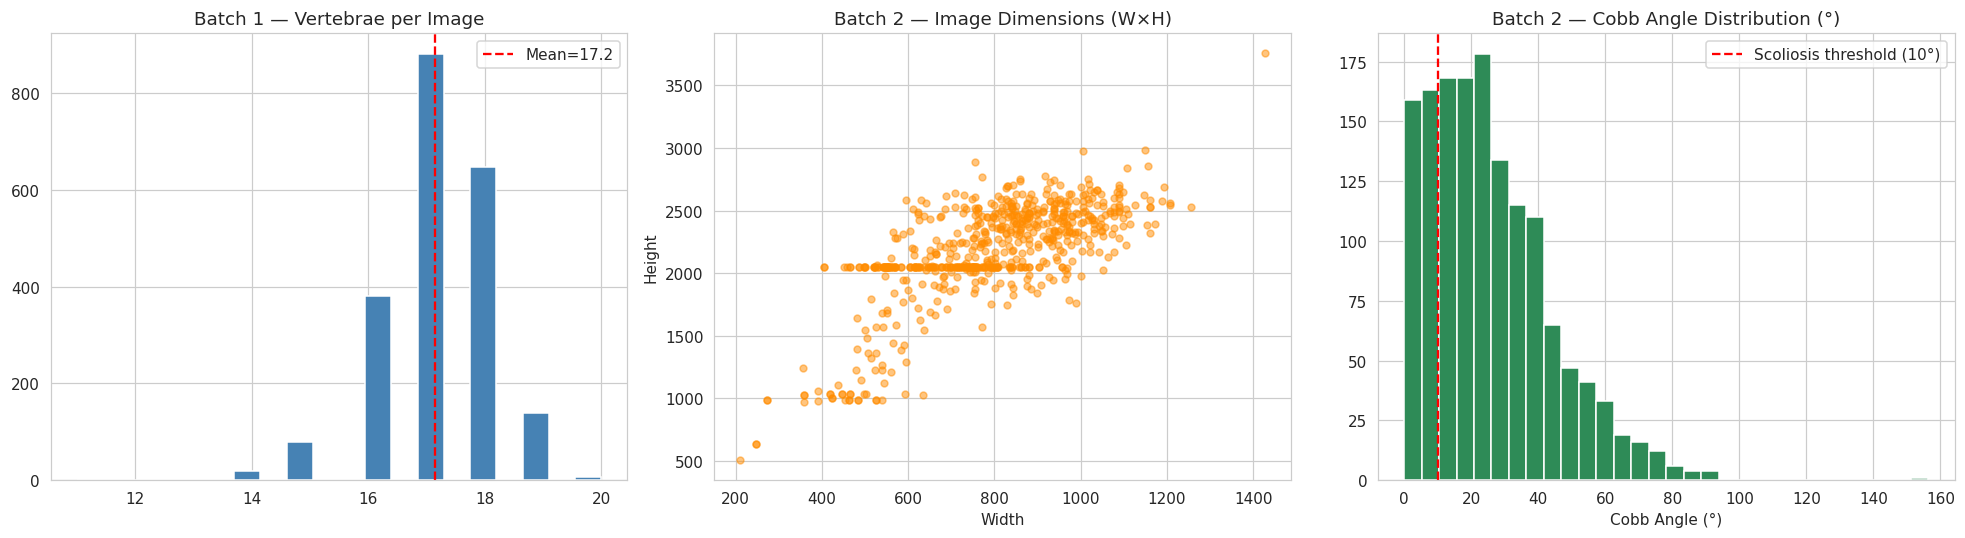

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Batch 1 — vertebrae per image
ax = axes[0]
if batch1_records:
    counts = [len(r['pts'])//4 for r in batch1_records]
    ax.hist(counts, bins=20, color='steelblue', edgecolor='white')
    ax.axvline(np.mean(counts),color='red',ls='--',label=f'Mean={np.mean(counts):.1f}')
    ax.set_title('Batch 1 — Vertebrae per Image'); ax.legend()
else:
    ax.text(0.5,0.5,'Batch 1 not loaded',ha='center',va='center',transform=ax.transAxes)
    ax.set_title('Batch 1 — Not Loaded')

# Batch 2 — image size scatter
ax = axes[1]
all_b2 = batch2_a + batch2_b
if all_b2:
    ws=[r['width'] for r in all_b2]; hs=[r['height'] for r in all_b2]
    ax.scatter(ws,hs,alpha=0.5,s=20,color='darkorange')
    ax.set_title('Batch 2 — Image Dimensions (W×H)')
    ax.set_xlabel('Width'); ax.set_ylabel('Height')
else:
    ax.text(0.5,0.5,'Batch 2 not loaded',ha='center',va='center',transform=ax.transAxes)
    ax.set_title('Batch 2 — Not Loaded')

# Batch 2 — Cobb angle distribution
ax = axes[2]
if df_angles is not None:
    flat = df_angles.values.flatten().astype(float)
    flat = flat[~np.isnan(flat)]
    ax.hist(flat,bins=30,color='seagreen',edgecolor='white')
    ax.axvline(10,color='red',ls='--',label='Scoliosis threshold (10°)')
    ax.set_title('Batch 2 — Cobb Angle Distribution (°)')
    ax.set_xlabel('Cobb Angle (°)'); ax.legend()
else:
    ax.text(0.5,0.5,'angles.csv not loaded',ha='center',va='center',transform=ax.transAxes)
    ax.set_title('Cobb Angle Distribution — Not Loaded')

plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR,'eda_overview.png'),bbox_inches='tight')
plt.show()

---
## 8. Experiment

In [ ]:
PHASE1_EPOCHS  = 30
PHASE2_EPOCHS  = 15
EARLY_STOP_PAT = 7

EXPERIMENTS = [
    {
        'name':          'exp_optimized_v1',
        'description':   'Best of both analyses: wide head + wh=3 + slow decay + warmup + rotation aug',
        'lr':            1.25e-4,
        'batch_size':    4,
        'head_conv':     512,
        'lr_gamma':      0.97,
        'wh_weight':     3.0,
        'warmup_epochs': 5,
        'use_rotation':  True,
        'max_angle':     8.0,
        'rot_p':         0.4,
    },
]

print(f'Single optimised experiment configured.')
pd.DataFrame([{k: v for k, v in e.items() if k != 'description'} for e in EXPERIMENTS]
             ).set_index('name')

Single optimised experiment configured.


,lr,batch_size,head_conv,lr_gamma,wh_weight,warmup_epochs,use_rotation,max_angle,rot_p
name,,,,,,,,,
exp_optimized_v1,0.000125,4,512,0.97,3.0,5,True,8.0,0.4


---
## 9. Training Infrastructure (from official train_vertenet.py)

In [ ]:
def build_phase1_loaders(batch_size, cfg=None):
    global _active_cfg
    _active_cfg = cfg or {}
    if batch1_records:
        tr, vl = train_test_split(batch1_records, test_size=VAL_SPLIT, random_state=SEED)
        _rot = _active_cfg.get('use_rotation', False)
        _ang = _active_cfg.get('max_angle', 8.0)
        _rp  = _active_cfg.get('rot_p', 0.4)
        train_ds = Batch1Dataset(tr, phase='train', num_vertebrae=K,
                                 use_rotation=_rot, max_angle=_ang, rot_p=_rp)
        val_ds   = Batch1Dataset(vl, phase='val',   num_vertebrae=K)
    else:
        print('  [!] No Batch 1 data — using synthetic dataset.')
        full = SyntheticSpineDataset(n=300)
        n_v  = int(len(full) * VAL_SPLIT)
        train_ds, val_ds = torch.utils.data.random_split(full, [len(full)-n_v, n_v])

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True,
                              drop_last=True, collate_fn=collater)
    val_loader   = DataLoader(val_ds,   batch_size=1, shuffle=False,
                              num_workers=1, pin_memory=True, collate_fn=collater)
    return train_loader, val_loader


def build_phase2_loaders(batch_size):
    all_b2 = batch2_a + batch2_b
    if all_b2:
        tr, vl   = train_test_split(all_b2, test_size=VAL_SPLIT, random_state=SEED)
        train_ds = Batch2Dataset(tr, phase='train', num_vertebrae=K)
        val_ds   = Batch2Dataset(vl, phase='val',   num_vertebrae=K)
    else:
        print('  [!] No Batch 2 data — using synthetic dataset.')
        full = SyntheticSpineDataset(n=200)
        n_v  = int(len(full) * VAL_SPLIT)
        train_ds, val_ds = torch.utils.data.random_split(full, [len(full)-n_v, n_v])

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True,
                              drop_last=True, collate_fn=collater)
    val_loader   = DataLoader(val_ds,   batch_size=1, shuffle=False,
                              num_workers=1, pin_memory=True, collate_fn=collater)
    return train_loader, val_loader


def run_epoch_vertenet(phase, model, loader, optimizer, criterion, device, scaler=None):
    """One epoch. Returns (total_loss, corner_mae_pixels)."""
    model.train() if phase == 'train' else model.eval()
    running_loss = 0.
    running_wh   = 0.
    n_batches    = 0
    ctx = torch.enable_grad() if phase == 'train' else torch.no_grad()
    with ctx:
        for data_dict in tqdm(loader, desc=f'  {phase:5s}', leave=False):
            for name in data_dict:
                data_dict[name] = data_dict[name].to(device)
            pr   = model(data_dict['input'])
            loss = criterion(pr, data_dict)
            with torch.no_grad():
                mask    = data_dict['reg_mask'].unsqueeze(2).float()
                ind     = data_dict['ind']
                b, c, h, w = pr['wh'].shape
                wh_feat = pr['wh'].permute(0,2,3,1).contiguous().view(b,-1,c)
                idx_exp = ind.unsqueeze(2).expand(b, ind.size(1), c)
                wh_pred = wh_feat.gather(1, idx_exp)
                wh_gt   = data_dict['wh']
                wh_mae  = ((wh_pred-wh_gt).abs()*mask).sum() / (mask.sum()*8+1e-6)
                running_wh += wh_mae.item()
            if phase == 'train':
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 10.0)
                optimizer.step()
            running_loss += loss.item()
            n_batches    += 1
    avg_loss      = running_loss / max(n_batches, 1)
    corner_mae_px = (running_wh  / max(n_batches, 1)) * DOWN_RATIO
    return avg_loss, corner_mae_px


@torch.no_grad()
def measure_inference_speed(model, device, img_size=512, n_iters=50):
    model.eval()
    dummy = torch.randn(1, 3, img_size, img_size, device=device)
    for _ in range(5): model(dummy)
    if device.type == 'cuda': torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(n_iters): model(dummy)
    if device.type == 'cuda': torch.cuda.synchronize()
    return round((time.perf_counter()-t0)/n_iters*1000, 2)


def save_model(path, epoch, model):
    sd = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()
    torch.save({'epoch': epoch, 'state_dict': sd}, path)


def load_model(model, path):
    ckpt = torch.load(path, map_location='cpu')
    sd   = {k[7:] if k.startswith('module') else k: v
            for k, v in ckpt['state_dict'].items()}
    model.load_state_dict(sd, strict=False)
    print(f'  Loaded weights (epoch {ckpt["epoch"]}) from {path}')
    return model


print('Training infrastructure loaded.')

Training infrastructure loaded.


---
## 10. Run All Experiments

In [ ]:
# Module-level variable — MUST be outside any function
_active_cfg = {}


def make_warmup_exp_scheduler(optimizer, warmup_epochs, gamma):
    """Linear warmup for warmup_epochs, then ExponentialLR with given gamma."""
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / max(warmup_epochs, 1)
        return gamma ** (epoch - warmup_epochs + 1)
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def run_experiment(cfg, phase=1, init_weights_path=None):
    global _active_cfg
    _active_cfg = cfg

    exp    = cfg['name']
    epochs = PHASE1_EPOCHS if phase == 1 else PHASE2_EPOCHS
    warmup = cfg.get('warmup_epochs', 0)

    print(f'\n{"="*72}')
    print(f'  Experiment : {exp}  |  Phase {phase}')
    print(f'  {cfg["description"]}')
    print(f'  warmup={warmup} epochs | rotation={cfg.get("use_rotation", False)}')
    print(f'{"="*72}')
    print(f'  {"Ep":>3}  {"":4}  {"Tr Loss":>9}  {"Vl Loss":>9}  '
          f'{"Tr MAE px":>10}  {"Vl MAE px":>10}  {"LR":>9}')

    heads = {'hm': NUM_CLASSES, 'reg': 2*NUM_CLASSES, 'wh': 2*4}
    model = VerteNet(heads=heads, pretrained=(phase==1),
                     down_ratio=DOWN_RATIO, final_kernel=1,
                     head_conv=cfg['head_conv']).to(DEVICE)
    if init_weights_path and os.path.exists(init_weights_path):
        model = load_model(model, init_weights_path)
    n_params = count_parameters(model)

    train_loader, val_loader = (
        build_phase1_loaders(cfg['batch_size'], cfg) if phase == 1
        else build_phase2_loaders(cfg['batch_size']))

    lr  = cfg['lr'] if phase == 1 else cfg['lr'] * 0.1
    opt = optim.Adam(model.parameters(), lr)
    sch = make_warmup_exp_scheduler(opt, warmup, cfg['lr_gamma'])

    criterion = LossAll(wh_weight=cfg['wh_weight'], off_weight=1.0)

    history  = {'train_loss':[], 'val_loss':[], 'train_mae':[], 'val_mae':[]}
    best_val = float('inf')
    best_sd  = None
    patience = 0
    t_start  = time.time()

    for epoch in range(1, epochs + 1):
        tr_loss, tr_mae = run_epoch_vertenet(
            'train', model, train_loader, opt, criterion, DEVICE)
        vl_loss, vl_mae = run_epoch_vertenet(
            'val',   model, val_loader,   opt, criterion, DEVICE)
        cur_lr = opt.param_groups[0]['lr']
        sch.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_mae'].append(tr_mae)
        history['val_mae'].append(vl_mae)

        phase_tag = 'warm' if epoch <= warmup else '    '
        star = ' ◀ best' if vl_loss < best_val else ''
        print(f'  {epoch:3d} {phase_tag}  {tr_loss:9.4f}  {vl_loss:9.4f}  '
              f'{tr_mae:10.2f}  {vl_mae:10.2f}  {cur_lr:9.2e}{star}')

        if vl_loss < best_val:
            best_val = vl_loss
            best_sd  = copy.deepcopy(
                model.module.state_dict()
                if isinstance(model, nn.DataParallel)
                else model.state_dict())
            patience = 0
        else:
            patience += 1
            if patience >= EARLY_STOP_PAT:
                print(f'  [Early stop] no improvement for {EARLY_STOP_PAT} epochs.')
                break

    best_path = os.path.join(WEIGHTS_DIR, f'{exp}_phase{phase}_best.pth')
    torch.save({'epoch': epoch, 'state_dict': best_sd}, best_path)
    model.load_state_dict(best_sd)
    inf_ms    = measure_inference_speed(model, DEVICE, img_size=INPUT_H)
    train_min = round((time.time() - t_start) / 60, 1)

    print(f'\n  Best val loss : {best_val:.4f}')
    print(f'  Best val MAE  : {min(history["val_mae"]):.2f} px')
    print(f'  Train time    : {train_min} min  |  Inference : {inf_ms} ms/img')

    return {
        'name':            exp,
        'description':     cfg['description'],
        'lr':              lr,
        'batch_size':      cfg['batch_size'],
        'head_conv':       cfg['head_conv'],
        'lr_gamma':        cfg['lr_gamma'],
        'wh_weight':       cfg['wh_weight'],
        'warmup_epochs':   warmup,
        'use_rotation':    cfg.get('use_rotation', False),
        'best_val_loss':   best_val,
        'best_val_mae_px': min(history['val_mae']),
        'final_train_loss':history['train_loss'][-1],
        'final_val_loss':  history['val_loss'][-1],
        'history':         history,
        'train_time_min':  train_min,
        'inference_ms':    inf_ms,
        'n_params':        n_params,
        'epochs_run':      epoch,
        'best_weights_path': best_path,
    }

print('run_experiment loaded — warmup + rotation + per-epoch MAE.')

run_experiment loaded — warmup + rotation + per-epoch MAE.


### 10.1 Phase 1 — Pre-training on Batch 1

In [ ]:
phase1_results = []
for cfg in EXPERIMENTS:
    r = run_experiment(cfg, phase=1)
    phase1_results.append(r)
print('\n Phase 1 complete for all experiments.')


  Experiment : exp_optimized_v1  |  Phase 1
  Best of both analyses: wide head + wh=3 + slow decay + warmup + rotation aug
  warmup=5 epochs | rotation=True
   Ep          Tr Loss    Vl Loss   Tr MAE px   Vl MAE px         LR


model.safetensors:   0%|          | 0.00/86.5M [00:00<?, ?B/s]

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


    1 warm     3.6489     2.9849        1.94        1.52   2.50e-05 ◀ best


    2 warm     2.5566     2.3770        1.28        1.27   5.00e-05 ◀ best


...

   26          0.9066     0.9077        0.46        0.50   6.59e-05


   27          0.9030     0.8816        0.46        0.50   6.40e-05 ◀ best


   28          0.8888     0.8526        0.45        0.46   6.20e-05 ◀ best


   29          0.8748     0.8278        0.44        0.46   6.02e-05 ◀ best


   30          0.8689     0.9119        0.45        0.46   5.84e-05

  Best val loss : 0.8278
  Best val MAE  : 0.46 px
  Train time    : 182.3 min  |  Inference : 49.51 ms/img

 Phase 1 complete for all experiments.


### 10.2 Phase 2 — Fine-tuning on Batch 2 (from Phase 1 best weights)

In [ ]:
phase2_results = []
for cfg, p1 in zip(EXPERIMENTS, phase1_results):
    r = run_experiment(cfg, phase=2, init_weights_path=p1['best_weights_path'])
    phase2_results.append(r)
print('\n Phase 2 complete for all experiments.')


  Experiment : exp_optimized_v1  |  Phase 2
  Best of both analyses: wide head + wh=3 + slow decay + warmup + rotation aug
  warmup=5 epochs | rotation=True
   Ep          Tr Loss    Vl Loss   Tr MAE px   Vl MAE px         LR
  Loaded weights (epoch 30) from /kaggle/working/vertenet_results/weights/exp_optimized_v1_phase1_best.pth


    1 warm     5.5854     4.6080        3.67        2.92   2.50e-06 ◀ best


    2 warm     3.7669     3.3441        2.52        2.46   5.00e-06 ◀ best


    3 warm     2.9784     2.9366        2.26        2.29   7.50e-06 ◀ best


    4 warm     2.7410     2.7905        2.18        2.25   1.00e-05 ◀ best


...

   11          2.2560     2.3492        1.85        1.91   1.04e-05 ◀ best


   12          2.2295     2.3248        1.82        1.89   1.01e-05 ◀ best


   13          2.2060     2.3534        1.81        1.93   9.80e-06


   14          2.1809     2.2884        1.78        1.86   9.50e-06 ◀ best


   15          2.1668     2.2716        1.76        1.86   9.22e-06 ◀ best

  Best val loss : 2.2716
  Best val MAE  : 1.86 px
  Train time    : 27.4 min  |  Inference : 49.46 ms/img

 Phase 2 complete for all experiments.


---
## 11. Comparative Analysis & Visualizations

In [ ]:
pal = plt.cm.tab10.colors
rows = []
for p1, p2 in zip(phase1_results, phase2_results):
    rows.append({
        'Experiment':        p2['name'],
        'LR':                p2['lr'],
        'Batch':             p2['batch_size'],
        'head_conv':         p2['head_conv'],
        'LR gamma':          p2['lr_gamma'],
        'wh_weight':         p2['wh_weight'],
        'P1 Best Val Loss':  round(p1['best_val_loss'],4),
        'P2 Best Val Loss':  round(p2['best_val_loss'],4),
        'P2 Final Train Loss': round(p2['final_train_loss'],4),
        'P2 Final Val Loss': round(p2['final_val_loss'],4),
        'Train Time (min)':  p2['train_time_min'],
        'Inference (ms)':    p2['inference_ms'],
        'Params (M)':        round(p2['n_params']/1e6,2),
        'Epochs Run':        p2['epochs_run'],
    })

df_res = pd.DataFrame(rows).set_index('Experiment').sort_values('P2 Best Val Loss')
df_res['Rank'] = range(1, len(df_res)+1)

print('\n========== RESULTS TABLE ==========')
print(df_res.to_string())
df_res.to_csv(os.path.join(OUTPUT_DIR,'comparative_results.csv'))
df_res


========== RESULTS TABLE ==========
                        LR  Batch  head_conv  LR gamma  wh_weight  P1 Best Val Loss  P2 Best Val Loss  P2 Final Train Loss  P2 Final Val Loss  Train Time (min)  Inference (ms)  Params (M)  Epochs Run  Rank
Experiment                                                                                                                                                                                                   
exp_optimized_v1  0.000013      4        512      0.97        3.0            0.8278            2.2716               2.1668             2.2716              27.4           49.46       23.05          15     1


,LR,Batch,head_conv,LR gamma,wh_weight,P1 Best Val Loss,P2 Best Val Loss,P2 Final Train Loss,P2 Final Val Loss,Train Time (min),Inference (ms),Params (M),Epochs Run,Rank
Experiment,,,,,,,,,,,,,,
exp_optimized_v1,0.000013,4,512,0.97,3.0,0.8278,2.2716,2.1668,2.2716,27.4,49.46,23.05,15,1


### 11.1 Learning Curves

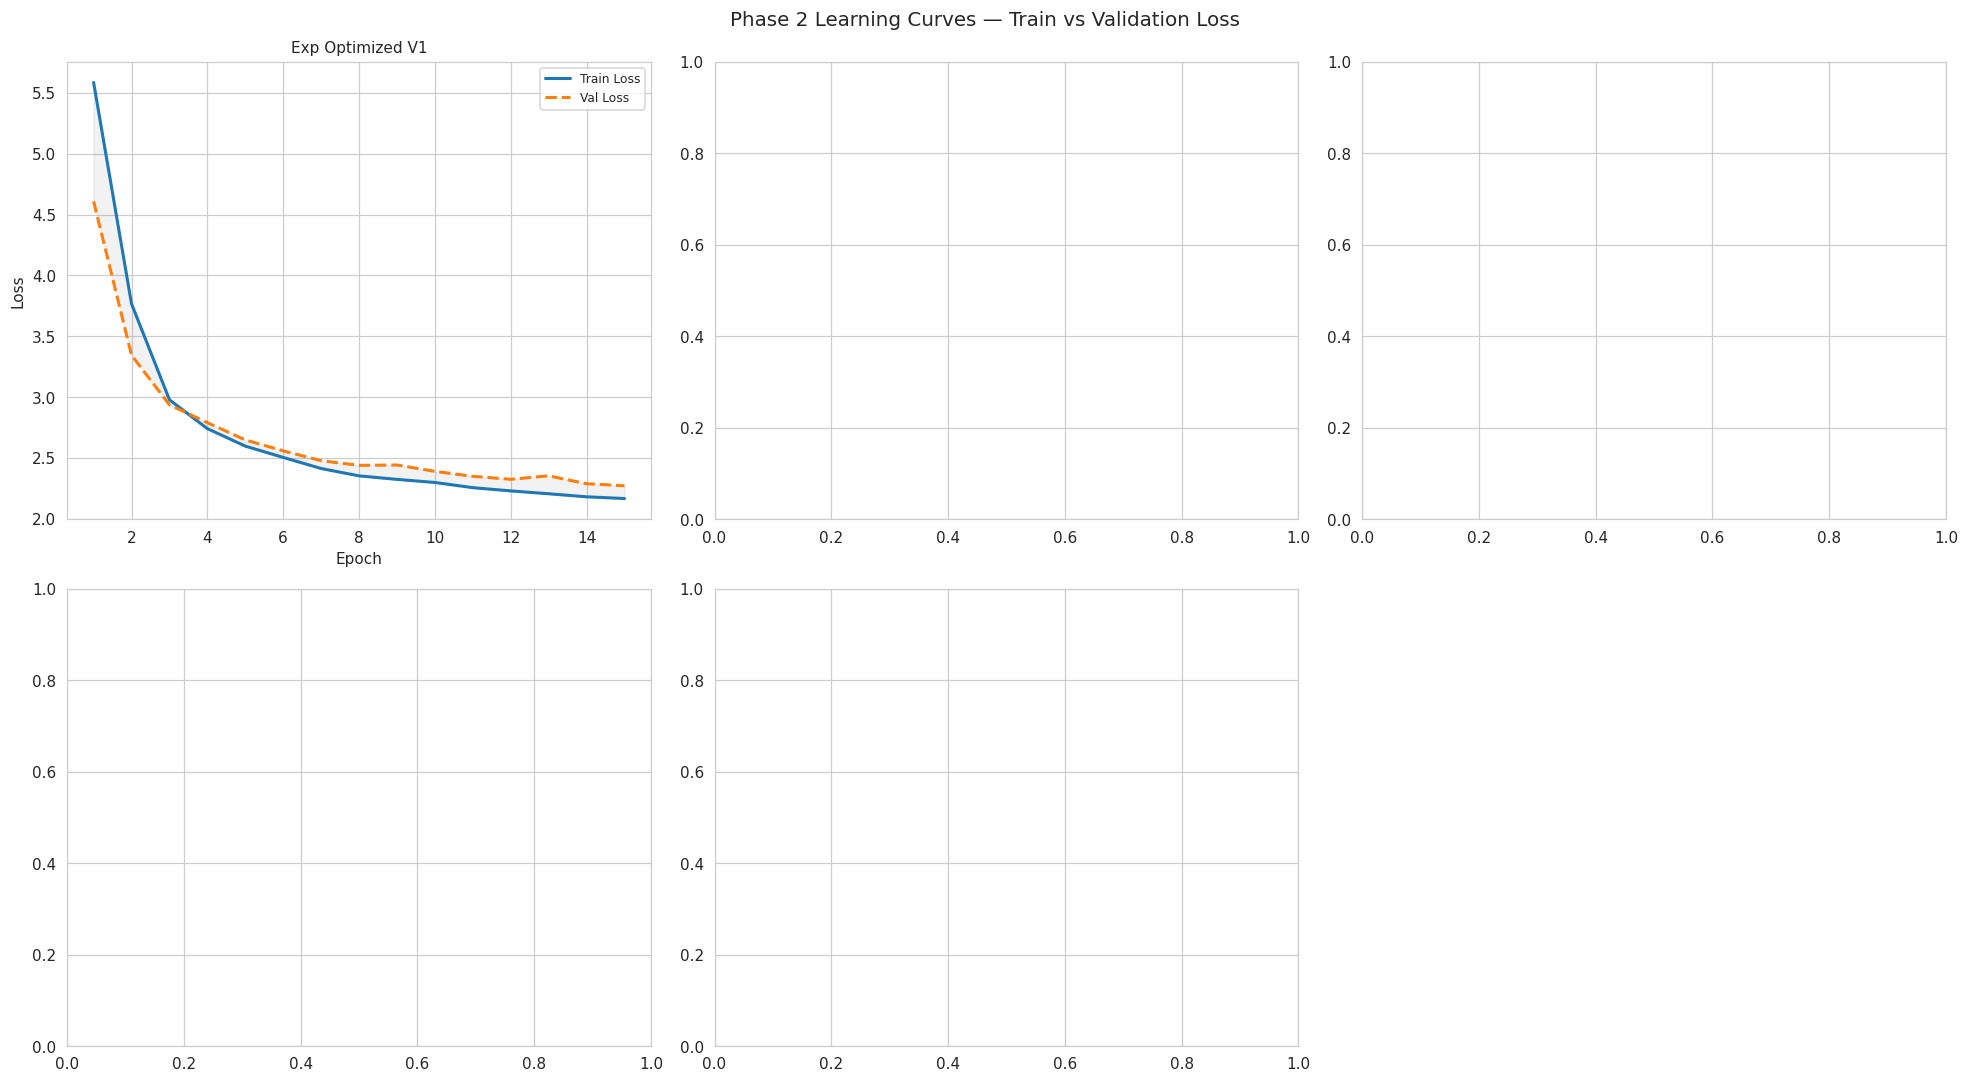

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18,10))
axes = axes.flatten()
for i, res in enumerate(phase2_results):
    ax  = axes[i]
    h   = res['history']
    eps = range(1, len(h['train_loss'])+1)
    ax.plot(eps, h['train_loss'], lw=2, color=pal[0], label='Train Loss')
    ax.plot(eps, h['val_loss'],   lw=2, color=pal[1], ls='--', label='Val Loss')
    ax.fill_between(eps, h['train_loss'], h['val_loss'], alpha=0.1, color='gray')
    ax.set_title(res['name'].replace('_',' ').title(), fontsize=10)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.legend(fontsize=8)
axes[-1].axis('off')
plt.suptitle('Phase 2 Learning Curves — Train vs Validation Loss', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR,'learning_curves.png'),bbox_inches='tight')
plt.show()

### 11.2 Hyperparameter vs Metric

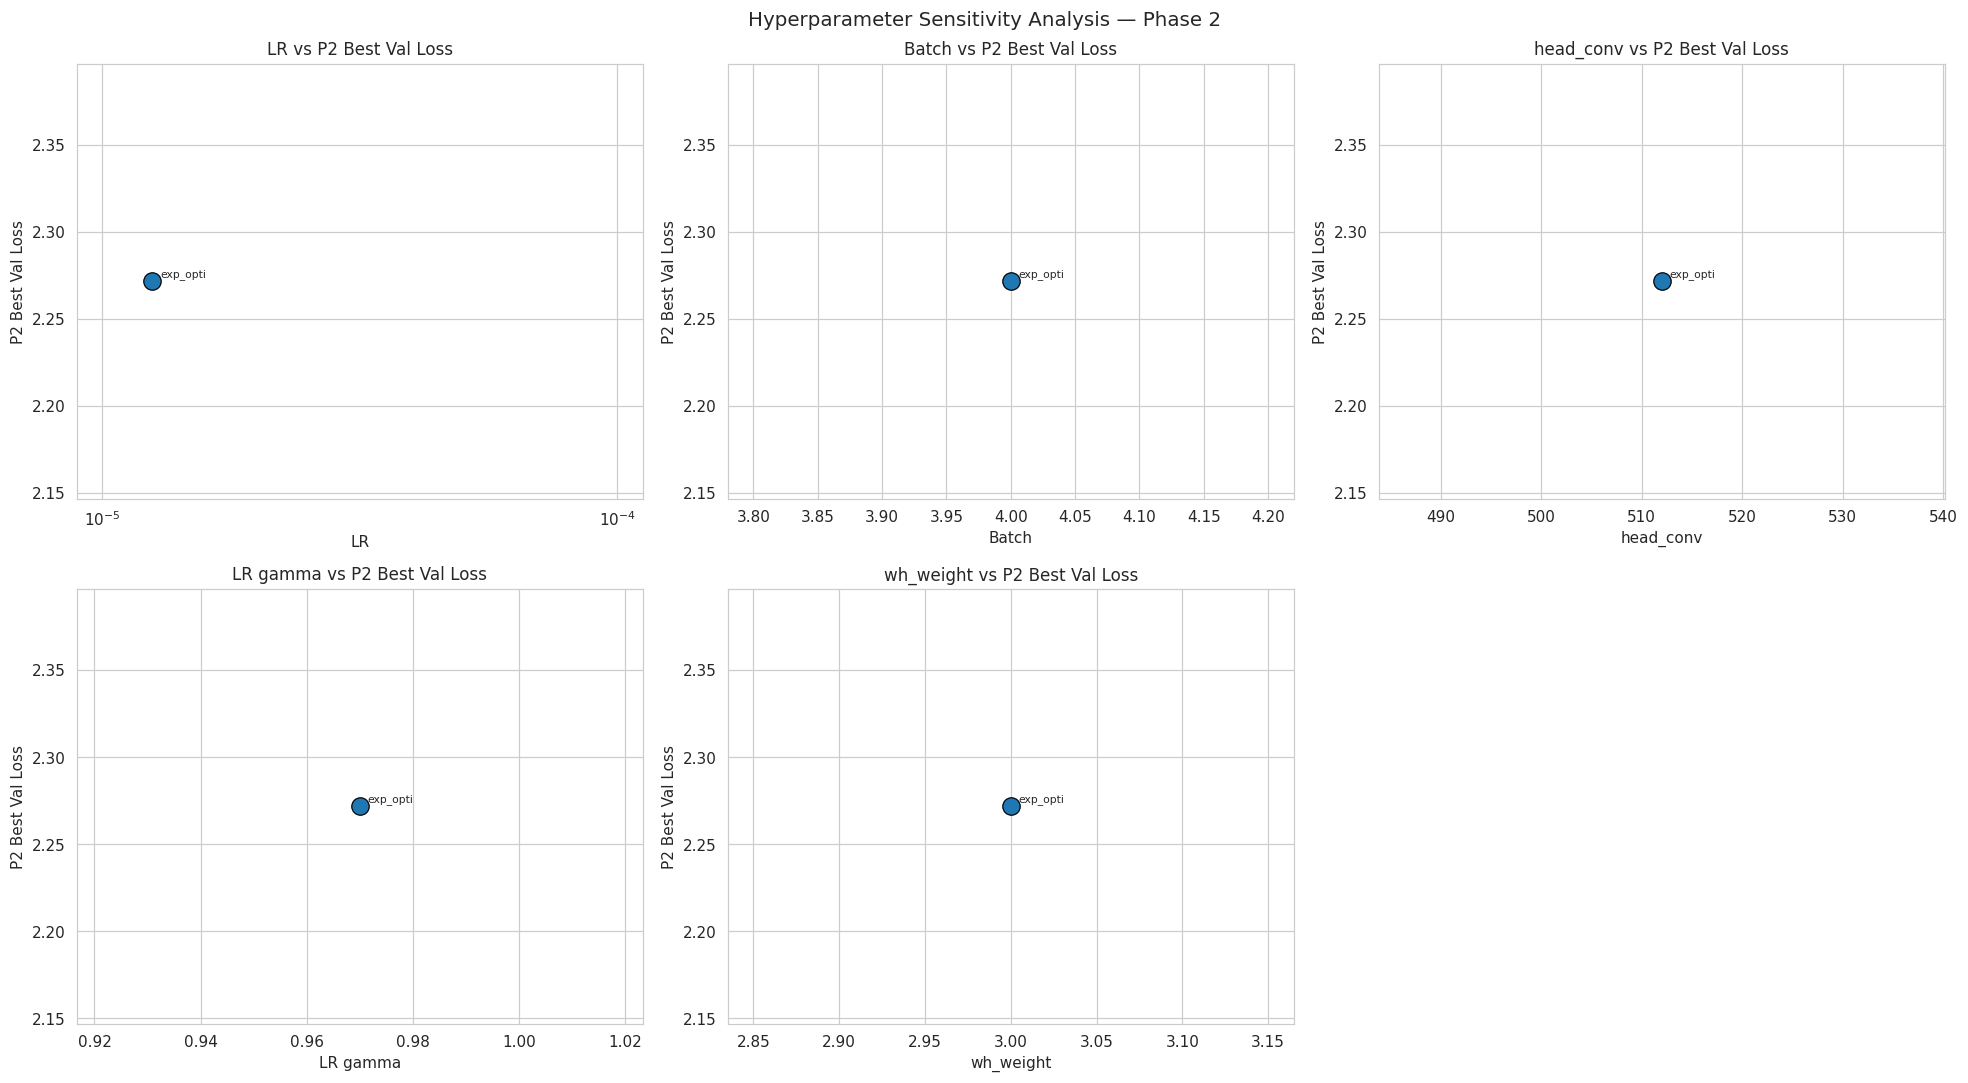

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18,10))
axes = axes.flatten()
metric = 'P2 Best Val Loss'
colors = [pal[i] for i in range(len(df_res))]
params = [('LR','log'),('Batch',None),('head_conv',None),('LR gamma',None),('wh_weight',None)]
for i, (param, scale) in enumerate(params):
    ax = axes[i]
    ax.scatter(df_res[param], df_res[metric], c=colors, s=130, zorder=5, edgecolors='k', lw=0.8)
    for name,row in df_res.iterrows():
        ax.annotate(name[:8],(row[param],row[metric]),
                    textcoords='offset points',xytext=(5,3),fontsize=7)
    if scale=='log': ax.set_xscale('log')
    ax.set_title(f'{param} vs {metric}', fontsize=11)
    ax.set_xlabel(param); ax.set_ylabel(metric)
axes[-1].axis('off')
plt.suptitle('Hyperparameter Sensitivity Analysis — Phase 2', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR,'hyperparameter_analysis.png'),bbox_inches='tight')
plt.show()

### 11.3 Efficiency — Training Time & Inference Speed

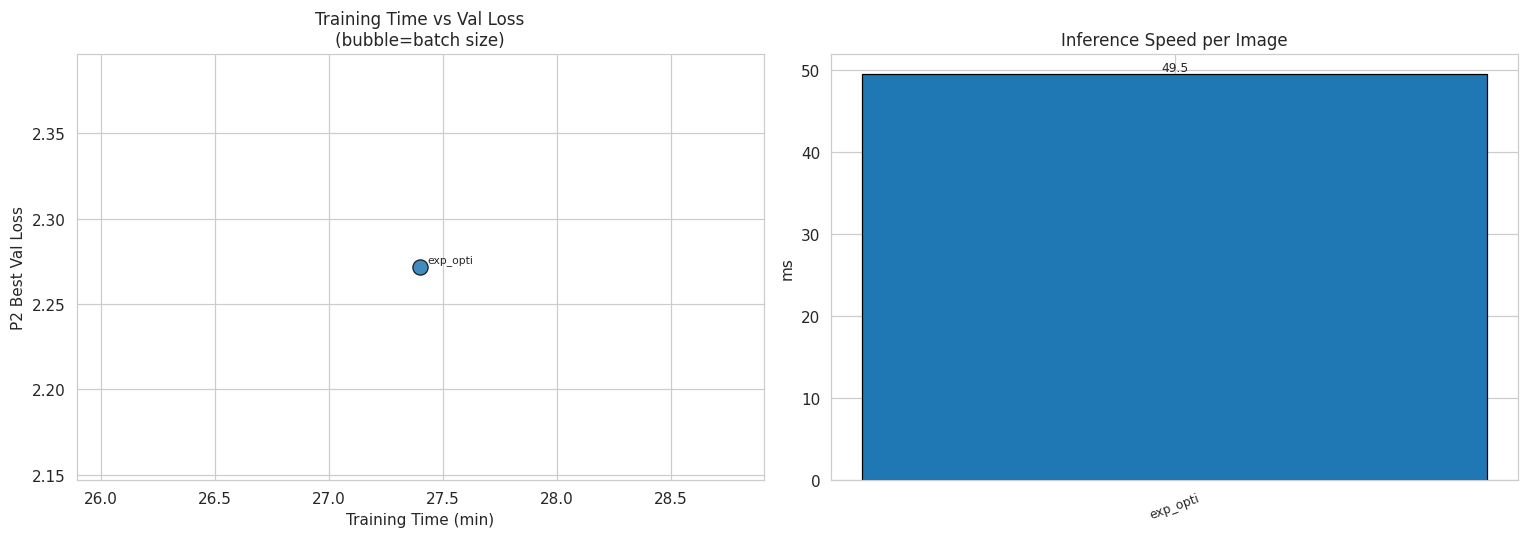

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
# Time vs Val Loss (bubble = batch size)
ax = axes[0]
szs = df_res['Batch'] * 25
ax.scatter(df_res['Train Time (min)'], df_res[metric], c=colors, s=szs,
           alpha=0.85, zorder=5, edgecolors='k', lw=0.8)
for name,row in df_res.iterrows():
    ax.annotate(name[:8],(row['Train Time (min)'],row[metric]),
                textcoords='offset points',xytext=(5,3),fontsize=7)
ax.set_title('Training Time vs Val Loss\n(bubble=batch size)', fontsize=11)
ax.set_xlabel('Training Time (min)'); ax.set_ylabel(metric)
# Inference speed bar chart
ax = axes[1]
bars = ax.bar(range(len(df_res)), df_res['Inference (ms)'], color=colors, edgecolor='k', lw=0.8)
ax.set_xticks(range(len(df_res)))
ax.set_xticklabels([n[:8] for n in df_res.index], rotation=20, fontsize=8)
ax.set_title('Inference Speed per Image', fontsize=11); ax.set_ylabel('ms')
for b in bars: ax.text(b.get_x()+b.get_width()/2, b.get_height(), f'{b.get_height():.1f}',
                        ha='center',va='bottom',fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR,'efficiency.png'),bbox_inches='tight')
plt.show()

### 11.4 Best Model — Heatmap Visualisation & Cobb Angle Evaluation

  Loaded weights (epoch 15) from /kaggle/working/vertenet_results/weights/exp_optimized_v1_phase2_best.pth


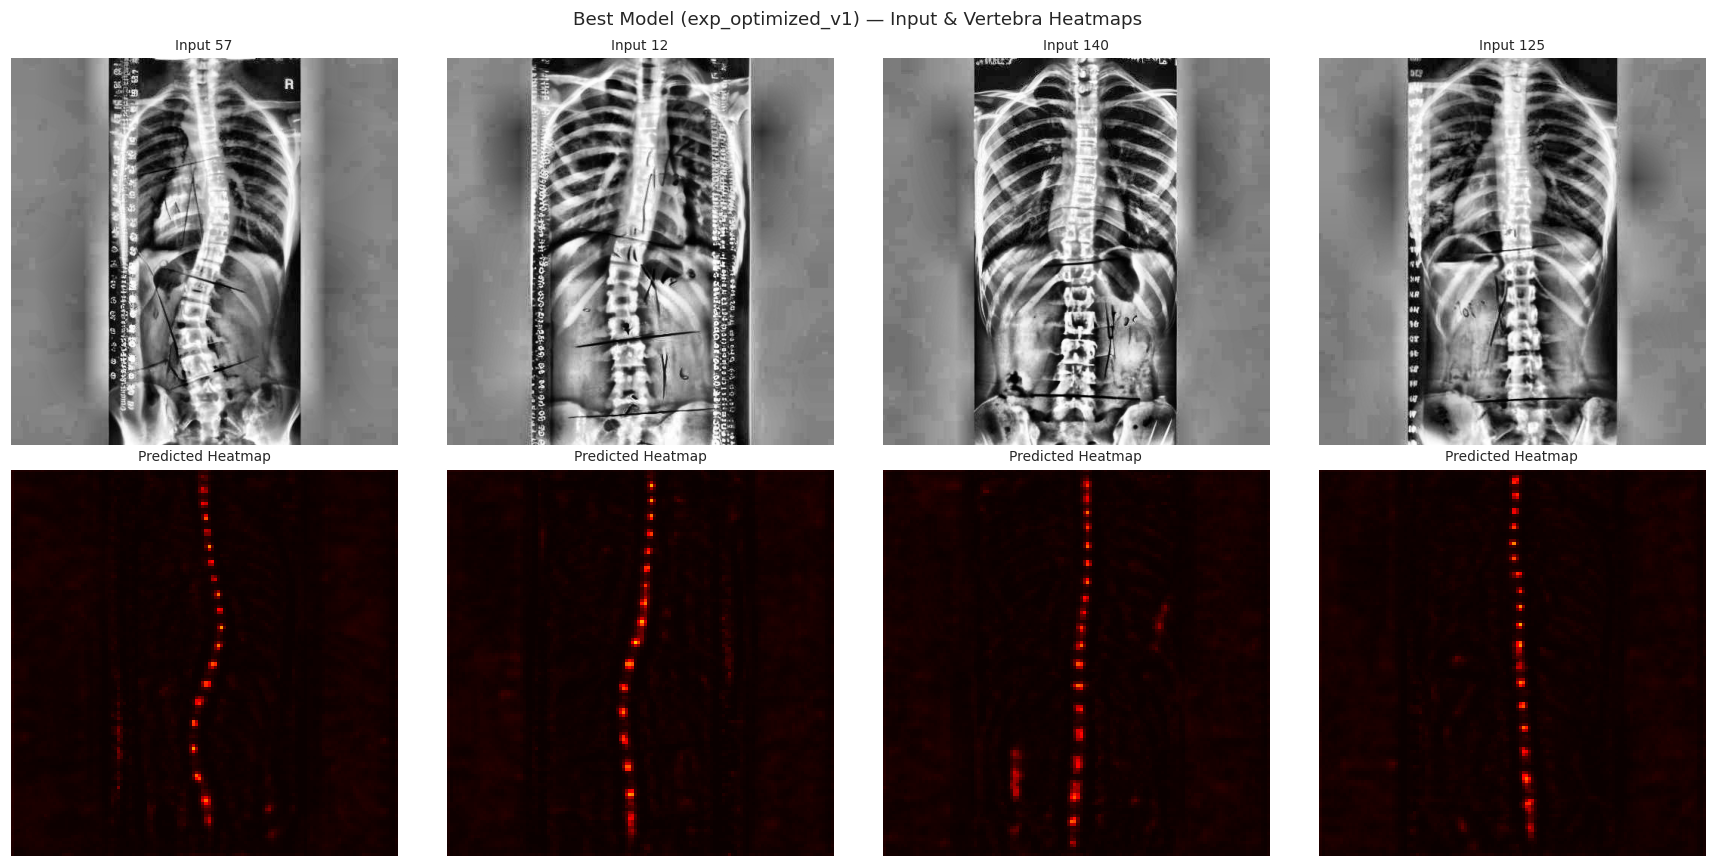

In [ ]:
# Load best model
best_exp_idx = int(df_res['Rank'].values.argmin())
best_cfg     = EXPERIMENTS[best_exp_idx]
best_res     = phase2_results[best_exp_idx]

heads = {'hm':NUM_CLASSES,'reg':2*NUM_CLASSES,'wh':2*4}
best_model = VerteNet(heads=heads, pretrained=False, down_ratio=DOWN_RATIO,
                      final_kernel=1, head_conv=best_cfg['head_conv']).to(DEVICE)
if os.path.exists(best_res['best_weights_path']):
    best_model = load_model(best_model, best_res['best_weights_path'])
best_model.eval()

decoder_obj = DecDecoder(K=K, conf_thresh=CONF_THRESH)

@torch.no_grad()
def visualise_heatmaps(model, dataset, device, n=4):
    model.eval()
    indices = random.sample(range(len(dataset)), min(n, len(dataset)))
    fig, axes = plt.subplots(2, n, figsize=(4*n, 8))
    for col, idx in enumerate(indices):
        data = dataset[idx]
        inp  = data['input'].unsqueeze(0).to(device)
        pr   = model(inp)
        # Raw image (denorm: img = (x+0.5)*255)
        img_np = (data['input'].permute(1,2,0).numpy() + 0.5).clip(0,1)
        hm_np  = pr['hm'][0, 0].cpu().numpy()   # (H/4, W/4)
        axes[0, col].imshow(img_np)
        axes[0, col].set_title(f'Input {idx}', fontsize=9); axes[0, col].axis('off')
        axes[1, col].imshow(hm_np, cmap='hot', vmin=0, vmax=1)
        axes[1, col].set_title('Predicted Heatmap', fontsize=9); axes[1, col].axis('off')
    plt.suptitle(f'Best Model ({best_res["name"]}) — Input & Vertebra Heatmaps', fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGS_DIR,'heatmap_visualisation.png'), bbox_inches='tight')
    plt.show()

# Use whichever val set we have
if batch1_records:
    _, vl_recs = train_test_split(batch1_records, test_size=VAL_SPLIT, random_state=SEED)
    vis_ds = Batch1Dataset(vl_recs, phase='val')
else:
    vis_ds = SyntheticSpineDataset(n=50)

visualise_heatmaps(best_model, vis_ds, DEVICE, n=4)

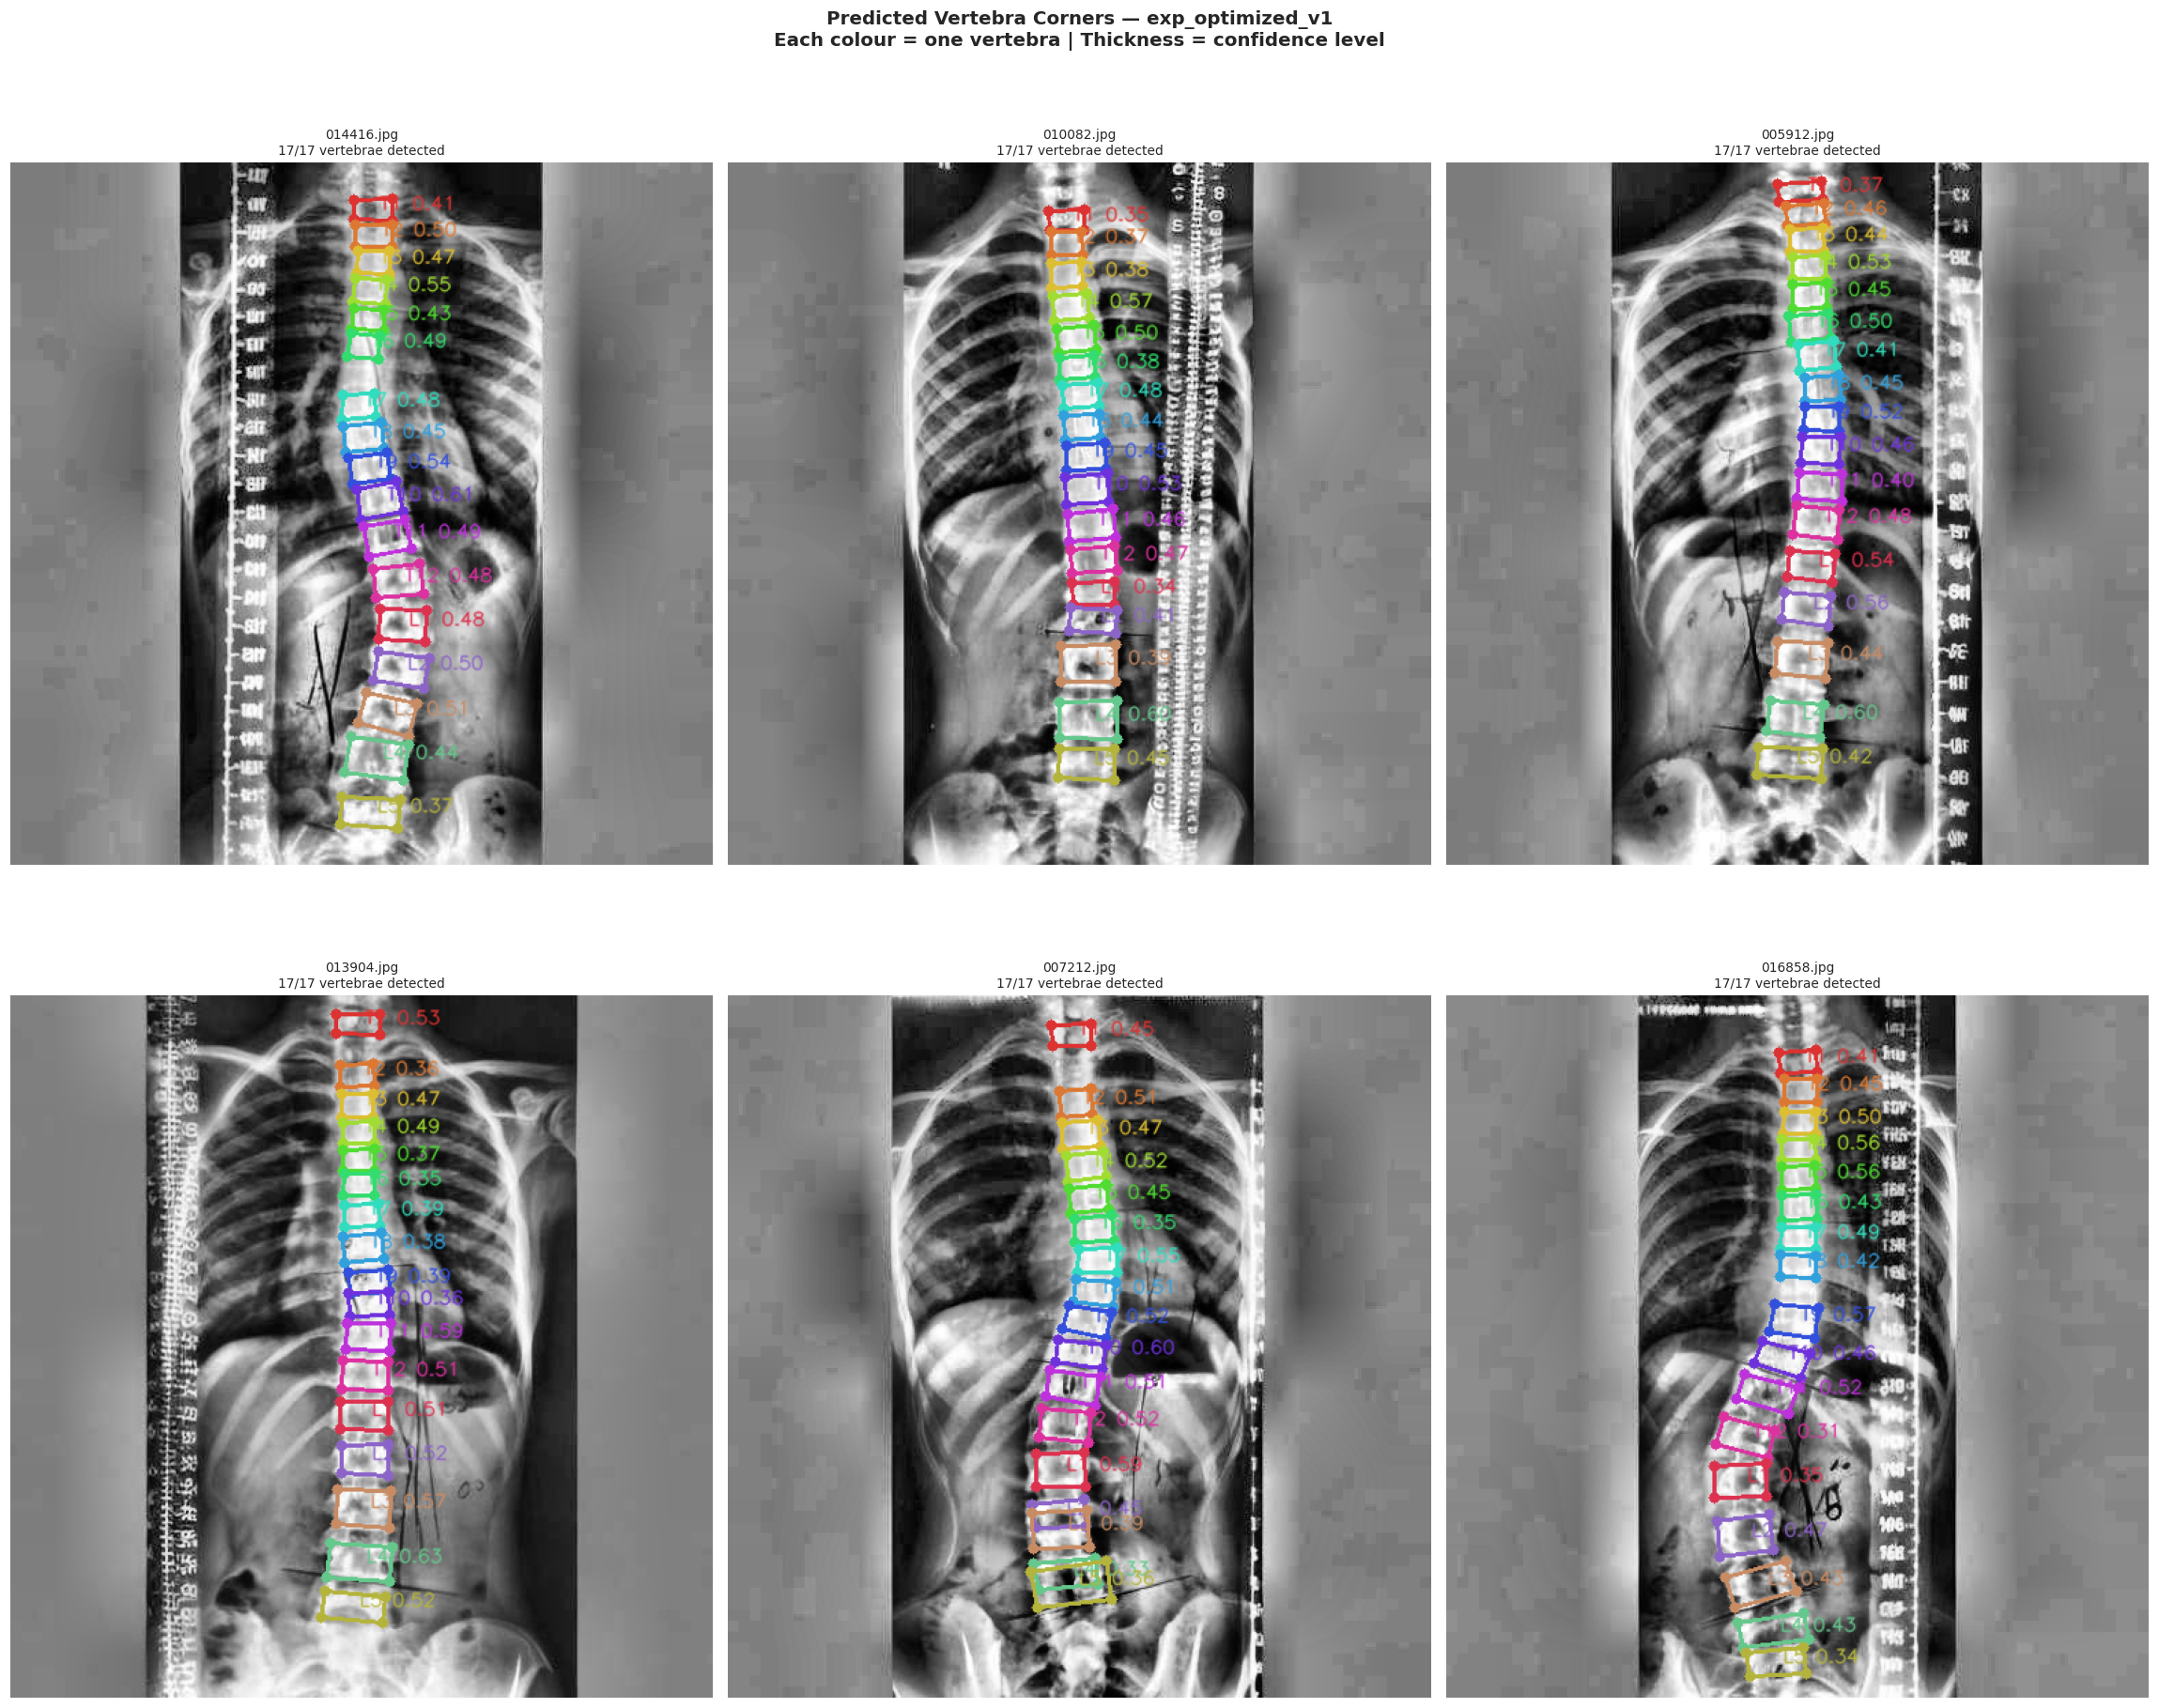

Saved: /kaggle/working/vertenet_results/figures/predicted_corners_validation.png


In [ ]:
# ── Visual Confirmation: 17 Predicted Vertebra Corners on Validation Images ──
@torch.no_grad()
def visualise_predicted_corners(model, records, decoder_obj, device, n=6):
    """
    Draw predicted 17-vertebra corners on validation images.
    Green box  = high-confidence detection (score > 0.3)
    Yellow box = lower-confidence detection (score 0.1–0.3)
    Each vertebra gets a unique colour cycling through 17 colours.
    """
    model.eval()
    sample = random.sample(records, min(n, len(records)))

    # 17 distinct colours for 17 vertebrae (BGR → RGB already handled by imshow)
    VERT_COLORS = [
        (220,  50,  50), (220, 120,  50), (220, 190,  50), (160, 220,  50),
        ( 80, 220,  50), ( 50, 220, 110), ( 50, 220, 190), ( 50, 160, 220),
        ( 50,  80, 220), (110,  50, 220), (190,  50, 220), (220,  50, 160),
        (220,  50,  80), (140, 100, 200), (200, 140, 100), (100, 200, 140),
        (180, 180,  60),
    ]
    VERT_NAMES = [
        'T1','T2','T3','T4','T5','T6','T7','T8',
        'T9','T10','T11','T12','L1','L2','L3','L4','L5'
    ]

    cols = min(n, 3)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(7*cols, 9*rows))
    axes = np.array(axes).flatten()

    for ax_i, rec in enumerate(sample):
        img_bgr = cv2.imread(rec['image_path'])
        if img_bgr is None:
            axes[ax_i].set_title('Image not found'); axes[ax_i].axis('off')
            continue

        # Resize to model input and run inference
        img_resized = cv2.resize(img_bgr, (INPUT_W, INPUT_H))
        inp_t = processing_test(img_resized, INPUT_H, INPUT_W).to(device)
        pr    = model(inp_t)

        # Decode top-K vertebrae
        dets = decoder_obj.ctdet_decode(pr['hm'], pr['wh'], pr['reg'])
        # dets: (K, 11) — cx,cy, tl_x,tl_y, tr_x,tr_y, bl_x,bl_y, br_x,br_y, score
        dets_np = dets.cpu().numpy() if hasattr(dets, 'cpu') else dets
        # Scale from heatmap space → image space
        dets_np[:, :10] *= DOWN_RATIO

        # Filter by confidence and sort top-to-bottom
        valid = dets_np[dets_np[:, -1] > CONF_THRESH]
        valid = valid[np.argsort(valid[:, 1])]   # sort by centre-y

        draw = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB).copy()

        n_detected = len(valid)
        for vi, det in enumerate(valid):
            col = VERT_COLORS[vi % len(VERT_COLORS)]
            lbl = VERT_NAMES[vi] if vi < len(VERT_NAMES) else f'V{vi}'
            score = det[-1]

            tl = det[2:4].astype(int)
            tr = det[4:6].astype(int)
            bl = det[6:8].astype(int)
            br = det[8:10].astype(int)
            cx, cy = int(det[0]), int(det[1])

            # Draw quadrilateral
            thickness = 2 if score > 0.3 else 1
            for p1, p2 in [(tl,tr),(tr,br),(br,bl),(bl,tl)]:
                cv2.line(draw, tuple(p1), tuple(p2), col, thickness)

            # Draw corner dots
            for pt in [tl, tr, bl, br]:
                cv2.circle(draw, tuple(pt), 4, col, -1)

            # Vertebra label
            cv2.putText(draw, f'{lbl} {score:.2f}',
                        (cx+5, cy), cv2.FONT_HERSHEY_SIMPLEX,
                        0.45, col, 1, cv2.LINE_AA)

        axes[ax_i].imshow(draw)
        fname = os.path.basename(rec['image_path'])
        axes[ax_i].set_title(
            f'{fname[:30]}\n{n_detected}/{K} vertebrae detected',
            fontsize=9)
        axes[ax_i].axis('off')

    # Hide unused axes
    for ax_i in range(len(sample), len(axes)):
        axes[ax_i].axis('off')

    plt.suptitle(
        f'Predicted Vertebra Corners — {best_res["name"]}\n'
        f'Each colour = one vertebra | Thickness = confidence level',
        fontsize=13, fontweight='bold')
    plt.tight_layout()
    save_path = os.path.join(FIGS_DIR, 'predicted_corners_validation.png')
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')


# ── Run it ────────────────────────────────────────────────────────────────
if batch1_records:
    _, vl_recs = train_test_split(batch1_records, test_size=VAL_SPLIT, random_state=SEED)
    vis_records = vl_recs
elif batch2_a or batch2_b:
    vis_records = (batch2_a + batch2_b)[:50]
else:
    vis_records = []

if vis_records:
    visualise_predicted_corners(best_model, vis_records, decoder_obj, DEVICE, n=6)
else:
    print('[Visual] No real records available — cannot draw corners.')

### 11.5 Cobb Angle MAE Evaluation (requires angles.csv + matched images)

Cobb eval: 100%|██████████| 50/50 [00:03<00:00, 15.67it/s]


Cobb Angle MAE  = 9.97°  (clinical target < 5°)
Cobb Angle RMSE = 12.88°


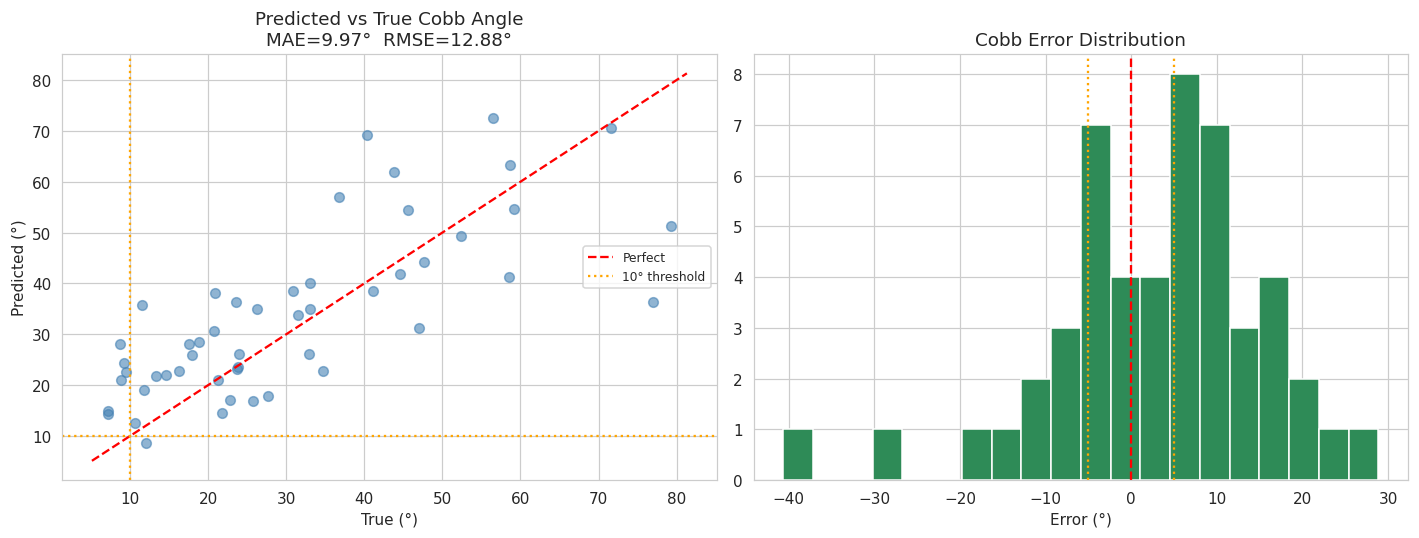

In [ ]:
@torch.no_grad()
def evaluate_cobb_mae(model, records, df_angles_csv, df_files_csv, device, n=50):
    if df_angles_csv is None or df_files_csv is None or not records:
        print('[Cobb MAE] Ground-truth CSV not available — skipping.')
        return None
    model.eval()
    fn2angle = {}
    filenames = df_files_csv.iloc[:,0].tolist()
    for i, fn in enumerate(filenames):
        fn2angle[os.path.splitext(fn)[0]] = df_angles_csv.values[i]

    paired = [(r, fn2angle[os.path.splitext(os.path.basename(r['image_path']))[0]])
              for r in records
              if os.path.splitext(os.path.basename(r['image_path']))[0] in fn2angle][:n]

    if not paired:
        print('[Cobb MAE] No filename matches found.'); return None

    pred_cobbs, true_cobbs = [], []
    for rec, gt_angles in tqdm(paired, desc='Cobb eval'):
        img = cv2.imread(rec['image_path'])
        if img is None: continue
        inp_t = processing_test(img, INPUT_H, INPUT_W).to(device)
        pr    = model(inp_t)
        pts_pred = decoder_obj.ctdet_decode(pr['hm'], pr['wh'], pr['reg'])
        # pts_pred: (K, 11) → cen_x,cen_y, tl_x,tl_y, tr_x,tr_y, bl_x,bl_y, br_x,br_y, score
        # scale back to original image space (×down_ratio)
        pts_raw = pts_pred[pts_pred[:, -1] > CONF_THRESH]
        if len(pts_raw) < 2: continue
        # Build (N*4, 2) corner array for cobb_angle_calc
        corners = []
        for row in pts_raw:
            tl = row[2:4]*DOWN_RATIO; tr = row[4:6]*DOWN_RATIO
            bl = row[6:8]*DOWN_RATIO; br = row[8:10]*DOWN_RATIO
            corners.extend([tl, tr, bl, br])
        corners = np.asarray(corners, np.float32)
        try:
            pred_cobb = cobb_angle_calc(corners)[0]
        except: continue
        true_cobb = float(np.nanmax(gt_angles.astype(float)))
        pred_cobbs.append(pred_cobb); true_cobbs.append(true_cobb)

    if not pred_cobbs: print('[Cobb MAE] No valid pairs.'); return None

    pred_arr = np.array(pred_cobbs); true_arr = np.array(true_cobbs)
    mae  = mean_absolute_error(true_arr, pred_arr)
    rmse = np.sqrt(mean_squared_error(true_arr, pred_arr))
    print(f'Cobb Angle MAE  = {mae:.2f}°  (clinical target < 5°)')
    print(f'Cobb Angle RMSE = {rmse:.2f}°')

    fig, axes = plt.subplots(1,2,figsize=(13,5))
    ax = axes[0]
    ax.scatter(true_arr, pred_arr, alpha=0.6, s=40, color='steelblue')
    lims = [min(true_arr.min(),pred_arr.min())-2, max(true_arr.max(),pred_arr.max())+2]
    ax.plot(lims,lims,'r--',lw=1.5,label='Perfect')
    ax.axvline(10,color='orange',ls=':'); ax.axhline(10,color='orange',ls=':',label='10° threshold')
    ax.set_title(f'Predicted vs True Cobb Angle\nMAE={mae:.2f}°  RMSE={rmse:.2f}°')
    ax.set_xlabel('True (°)'); ax.set_ylabel('Predicted (°)'); ax.legend(fontsize=8)
    ax = axes[1]
    errs = pred_arr - true_arr
    ax.hist(errs, bins=20, color='seagreen', edgecolor='white')
    ax.axvline(0,color='red',ls='--'); ax.axvline(5,color='orange',ls=':'); ax.axvline(-5,color='orange',ls=':')
    ax.set_title('Cobb Error Distribution'); ax.set_xlabel('Error (°)')
    plt.tight_layout()
    plt.savefig(os.path.join(FIGS_DIR,'cobb_evaluation.png'),bbox_inches='tight')
    plt.show()
    return {'mae':round(mae,3),'rmse':round(rmse,3)}


cobb_metrics = evaluate_cobb_mae(
    best_model, batch2_a+batch2_b, df_angles, df_files, DEVICE)

---
## 12. Final Summary Report

In [ ]:
print('\n'+'='*75)
print('           VerteNet — FINAL EXPERIMENT SUMMARY')
print('='*75)
best_row = df_res.iloc[0]
print(f'\n BEST CONFIG : {df_res.index[0]}')
print(f' Description : {best_res["description"]}')
print(f'\n Hyperparameters:')
print(f'   LR            : {best_row["LR"]}')
print(f'   Batch Size    : {int(best_row["Batch"])}')
print(f'   head_conv     : {int(best_row["head_conv"])}')
print(f'   LR gamma      : {best_row["LR gamma"]}')
print(f'   wh_weight     : {best_row["wh_weight"]}')
print(f'\n Performance:')
print(f'   P1 Best Val Loss       : {best_row["P1 Best Val Loss"]:.4f}')
print(f'   P2 Best Val Loss       : {best_row["P2 Best Val Loss"]:.4f}')
print(f'   P2 Final Train Loss    : {best_row["P2 Final Train Loss"]:.4f}')
if cobb_metrics:
    print(f'   Cobb MAE               : {cobb_metrics["mae"]:.2f}° (clinical target <5°)')
    print(f'   Cobb RMSE              : {cobb_metrics["rmse"]:.2f}°')
    print(f'   Clinical pass          : {"YES" if cobb_metrics["mae"]<5 else "NOT YET"}')
print(f'\n Efficiency:')
print(f'   Trainable Params (M)   : {best_row["Params (M)"]}')
print(f'   Inference Speed        : {best_row["Inference (ms)"]} ms/image')
print(f'   Training Time (P2)     : {best_row["Train Time (min)"]} min')
print(f'   Epochs Run             : {int(best_row["Epochs Run"])}')
print(f'\n All Experiments Ranked:')
print(df_res[['P2 Best Val Loss','P2 Final Train Loss','Train Time (min)','Inference (ms)','Params (M)','Rank']].to_string())

summary_out = {
    'best_experiment': df_res.index[0],
    'hyperparameters': {'lr':float(best_row['LR']),'batch_size':int(best_row['Batch']),
                        'head_conv':int(best_row['head_conv']),'lr_gamma':float(best_row['LR gamma']),
                        'wh_weight':float(best_row['wh_weight'])},
    'performance': {'p2_best_val_loss':float(best_row['P2 Best Val Loss']),
                    'p2_final_train_loss':float(best_row['P2 Final Train Loss']),
                    'cobb_mae_deg': cobb_metrics['mae'] if cobb_metrics else None,
                    'cobb_rmse_deg': cobb_metrics['rmse'] if cobb_metrics else None},
    'efficiency': {'params_M':float(best_row['Params (M)']),'inference_ms':float(best_row['Inference (ms)']),
                   'train_time_min':float(best_row['Train Time (min)'])},
    'all_experiments': df_res.reset_index().to_dict(orient='records'),
}
with open(os.path.join(OUTPUT_DIR,'final_summary.json'),'w') as f:
    json.dump(summary_out, f, indent=2)

print('\n'+'='*75)
print(f' Outputs saved to: {OUTPUT_DIR}')
print('   weights/    → best + final + epoch checkpoints per experiment')
print('   logs/       → per-experiment JSON + train_loss.txt + val_loss.txt')
print('   figures/    → EDA, learning curves, hyperparameter analysis,')
print('                 efficiency, heatmaps, Cobb angle evaluation')
print('   comparative_results.csv  +  final_summary.json')
print('='*75)


           VerteNet — FINAL EXPERIMENT SUMMARY

 BEST CONFIG : exp_optimized_v1
 Description : Best of both analyses: wide head + wh=3 + slow decay + warmup + rotation aug

 Hyperparameters:
   LR            : 1.25e-05
   Batch Size    : 4
   head_conv     : 512
   LR gamma      : 0.97
   wh_weight     : 3.0

 Performance:
   P1 Best Val Loss       : 0.8278
   P2 Best Val Loss       : 2.2716
   P2 Final Train Loss    : 2.1668
   Cobb MAE               : 9.97° (clinical target <5°)
   Cobb RMSE              : 12.88°
   Clinical pass          : NOT YET

 Efficiency:
   Trainable Params (M)   : 23.05
   Inference Speed        : 49.46 ms/image
   Training Time (P2)     : 27.4 min
   Epochs Run             : 15

 All Experiments Ranked:
                  P2 Best Val Loss  P2 Final Train Loss  Train Time (min)  Inference (ms)  Params (M)  Rank
Experiment                                                                                                 
exp_optimized_v1            2.2716       

---
## 13. Package Everything for Download

In [ ]:
import zipfile
zip_out = '/kaggle/working/vertenet_all_results.zip'
with zipfile.ZipFile(zip_out,'w',zipfile.ZIP_DEFLATED) as zf:
    for root,_,files in os.walk(OUTPUT_DIR):
        for file in files:
            fp = os.path.join(root,file)
            zf.write(fp, os.path.relpath(fp,'/kaggle/working'))
size_mb = os.path.getsize(zip_out)/1e6
print(f'Packaged: {zip_out}  ({size_mb:.1f} MB)')
print('Download: Kaggle sidebar → Output → vertenet_all_results.zip')

Packaged: /kaggle/working/vertenet_all_results.zip  (175.8 MB)
Download: Kaggle sidebar → Output → vertenet_all_results.zip


---
## Appendix: Dataset Path Checklist

| Variable | Points to | Example |
|---|---|---|
| `BATCH1_IMG` | Folder of 512×512 JPEGs | `/kaggle/input/batch1/images` |
| `BATCH1_JSON` | COCO annotations.json | `/kaggle/input/batch1/annotations.json` |
| `BATCH2_IMAGES_A` | High-res JPEGs set A | `/kaggle/input/batch2/Images` |
| `BATCH2_LABELS_A` | YOLO .txt labels A | `/kaggle/input/batch2/Labels` |
| `BATCH2_IMAGES_B` | High-res JPEGs set B | `/kaggle/input/batch2/Images2` |
| `BATCH2_LABELS_B` | YOLO .txt labels B | `/kaggle/input/batch2/Labels2` |
| `BATCH2_TRAIN_DIR` | Per-image .mat files | `/kaggle/input/batch2/Labels2/train` |
| `BATCH2_ANGLES_CSV` | Ground-truth Cobb angles | `/kaggle/input/batch2/Labels2/angles.csv` |
| `BATCH2_FILENAMES_CSV` | Matching filenames | `/kaggle/input/batch2/Labels2/filenames.csv` |

### Architecture Explanation (for your report)
- **Backbone**: EfficientNetV2-S extracts multi-scale features at [24, 48, 64, 160, 256] channels
- **Decoder novelty**: `CombinationModule_proposed` replaces the standard skip-connection with a **Dual-Resolution Cross-Attention (DR-CA)** block. It applies cross-attention between encoder features (key/value) and decoder features (query) at both original and 2× downsampled resolution simultaneously, then upsamples and concatenates for full spatial coverage
- **Heads (CenterNet-style)**:
  - `hm` (1 ch): Gaussian heatmap of vertebra centres — FocalLoss (class-imbalance aware)
  - `reg` (2 ch): Sub-pixel offset from integer centre — L1Loss
  - `wh` (8 ch): Vector from centre to each of 4 corners — L1Loss
- **Cobb angle**: Decoded corner points → endplate slopes → angular difference
- **Phase 2 letterboxing**: Preserves aspect ratio so no angular distortion is introduced